# I/O-safe all-Sweden final CNN

This notebook contains both epoch policies:

- `median15`: median of all 15 inner-fold best epochs.
- `median3`: median of the selected configuration's 3 inner-fold best epochs.

Recommended workflow:

1. Run the settings cell with `CHECK_ONLY = True`.
2. Verify the dataset, nested-result path, selected configuration, and fixed epoch count.
3. Change `CHECK_ONLY = False`.
4. Run the main cell once.
5. Run the final display cell to view the saved figures.

The training code avoids repeated full-file hashing, uses `N_WORKERS=0`, reads the large PKL once, keeps resume checkpoints on local `/tmp`, and writes the final network checkpoint to `/mnt/home` only once.

In [1]:
# =========================
# JupyterLab run settings
# =========================

# Choose ONE:
#   "median15" -> median of all 15 inner-fold best epochs
#   "median3"  -> median of the selected configuration's 3 inner-fold best epochs
EPOCH_MODE = "median15"

PROJECT_ROOT = "/mnt/home/qinqiu/thesis"

# First run with CHECK_ONLY=True. It validates paths and prints the selected
# configuration/epochs without loading the large PKL.
CHECK_ONLY = False

# Set True only when you intentionally want to discard the matching local
# /tmp resume checkpoint and restart training from epoch 1.
IGNORE_LOCAL_RESUME = False

# Optional path overrides. Leave as None to use the defaults.
COMMON_DATA_PKL_OVERRIDE = None
NESTED_EXP_ROOT_OVERRIDE = None
FINAL_EXP_ROOT_OVERRIDE = None
LOCAL_SCRATCH_ROOT_OVERRIDE = None

# Apply optional overrides as environment variables used by the main cell.
import os

if COMMON_DATA_PKL_OVERRIDE:
    os.environ["COMMON_DATA_PKL"] = COMMON_DATA_PKL_OVERRIDE
else:
    os.environ.pop("COMMON_DATA_PKL", None)

if NESTED_EXP_ROOT_OVERRIDE:
    os.environ["NESTED_EXP_ROOT"] = NESTED_EXP_ROOT_OVERRIDE
else:
    os.environ.pop("NESTED_EXP_ROOT", None)

if FINAL_EXP_ROOT_OVERRIDE:
    FINAL_EXP_ROOT = FINAL_EXP_ROOT_OVERRIDE
else:
    globals().pop("FINAL_EXP_ROOT", None)
    os.environ.pop("FINAL_EXP_ROOT", None)

if LOCAL_SCRATCH_ROOT_OVERRIDE:
    os.environ["FINAL_CNN_LOCAL_SCRATCH"] = LOCAL_SCRATCH_ROOT_OVERRIDE
else:
    os.environ.pop("FINAL_CNN_LOCAL_SCRATCH", None)

print("EPOCH_MODE:", EPOCH_MODE)
print("CHECK_ONLY:", CHECK_ONLY)
print("PROJECT_ROOT:", PROJECT_ROOT)


EPOCH_MODE: median15
CHECK_ONLY: False
PROJECT_ROOT: /mnt/home/qinqiu/thesis


## Main training cell

This is the complete self-contained training code. It does not require either of the separate `.py` files.

In [2]:
# ============================================================
# I/O-safe final all-Sweden CNN refit
# Epoch policy: median of all 15 inner-fold best epochs
# ============================================================
#
# This script does NOT rerun nested CV or Optuna. It:
#   1) reads the five saved outer-fold best_params.json files;
#   2) selects the configuration with the lowest INNER-CV patient MAE;
#   3) chooses the fixed epoch count using the median of all inner-fold best epochs from all five outer-best trials (normally 15 values);
#   4) trains one CNN on all valid patients in the Swedish common17 PKL;
#   5) saves one deployment checkpoint with frozen Swedish normalization;
#   6) creates reportable nested-OOF figures and clearly labelled apparent-fit
#      diagnostic figures.
#
# I/O safety changes relative to the earlier version:
#   - no full-file SHA256 scans of the large PKL;
#   - the PKL is read exactly once;
#   - no concatenation of all windows and no second normalized full copy;
#   - streaming patient-balanced normalization;
#   - N_WORKERS=0 (safe inside Jupyter);
#   - no large checkpoint writes to /mnt/home during training;
#   - resume checkpoint is written only to local /tmp every few epochs;
#   - final network checkpoint is written once, by sequentially copying a
#     locally created file;
#   - no window-level prediction CSV is written.
# ============================================================

from __future__ import annotations

import argparse
import bisect
import gc
import hashlib
import json
import math
import os
import pickle
import random
import shutil
import sys
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, Iterator, List, Mapping, Optional, Sequence, Tuple

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader, Dataset, Sampler


# ============================================================
# 0. Paths and safe runtime configuration
# ============================================================
SEED = int(globals().get("SEED", 42))
EPOCH_MODE = str(globals().get("EPOCH_MODE", "median3")).strip().lower()
if EPOCH_MODE not in {"median15", "median3"}:
    raise ValueError("EPOCH_MODE must be either 'median15' or 'median3'.")

PROJECT_ROOT = str(
    globals().get(
        "PROJECT_ROOT",
        os.environ.get("THESIS_PROJECT_ROOT", "/mnt/home/qinqiu/thesis"),
    )
)

COMMON_DATA_PKL = os.environ.get(
    "COMMON_DATA_PKL",
    os.path.join(
        PROJECT_ROOT,
        "data",
        "sweden_usa_common_feature_120min_stride40min",
        "sweden_120min_stride40min_usa_common17_imputed_2ch_CTHW.pkl",
    ),
)

NESTED_EXP_NAME = (
    "nested_cv_120min_stride40min_usa_common17_v1_"
    "patientbalanced_resume100"
)
NESTED_ROOT_CANDIDATES = [
    os.environ.get("NESTED_EXP_ROOT", ""),
    os.path.join(PROJECT_ROOT, "result_val", NESTED_EXP_NAME),
    os.path.join(PROJECT_ROOT, "result_nested", NESTED_EXP_NAME),
]

DEFAULT_FINAL_EXP_ROOT = os.path.join(
    PROJECT_ROOT,
    "result_val",
    (
        "final_all_sweden_common17_cnn_io_safe_median15"
        if EPOCH_MODE == "median15"
        else "final_all_sweden_common17_cnn_io_safe_selected_median3"
    ),
)
FINAL_EXP_ROOT = str(
    globals().get(
        "FINAL_EXP_ROOT",
        os.environ.get("FINAL_EXP_ROOT", DEFAULT_FINAL_EXP_ROOT),
    )
)

LOCAL_SCRATCH_ROOT = os.environ.get(
    "FINAL_CNN_LOCAL_SCRATCH",
    os.path.join(os.environ.get("TMPDIR", "/tmp"), "qinqiu_final_cnn_io_safe"),
)

FINAL_REFIT_SEED = 42
MAX_EPOCHS = 300
N_WORKERS = 0
PIN_MEMORY = False
LOCAL_CHECKPOINT_EVERY_EPOCHS = 5
PRINT_EVERY_BATCHES = 100
PRED_BATCH_SIZE = 512
FIGURE_DPI = 170
PMA_BIN_WIDTH_WEEKS = 0.5

PATIENT_BALANCED_NORMALIZATION = True
PATIENT_BALANCED_TRAINING = True
CONFIG_SELECTION_POLICY = "lowest_inner_mae_among_outer_best_trials"
EPOCH_SELECTION_POLICY = (
    "median_all_15_inner_epochs"
    if EPOCH_MODE == "median15"
    else "median_selected_configuration_3_inner_epochs"
)
CODE_VERSION = (
    "all_sweden_common17_io_safe_median15_notebook_v1"
    if EPOCH_MODE == "median15"
    else "all_sweden_common17_io_safe_selected_median3_notebook_v1"
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

COMMON_DYNAMIC_FEATURES = [
    "feats__spo2_mean",
    "feats__spo2_std",
    "feats__spo2_max",
    "feats__spo2_min",
    "feats__spo2_skew",
    "feats__spo2_kurtosis",
    "feats__btb_mean",
    "feats__btb_std",
    "feats__btb_max",
    "feats__btb_min",
    "feats__btb_skew",
    "feats__btb_kurtosis",
    "feats__btb_sampAs",
    "feats__btb_sampEn",
]
STATIC_FEATURES = ["feats__ga_w", "feats__sex", "feats__bw"]
EXPECTED_FEATURES = COMMON_DYNAMIC_FEATURES + STATIC_FEATURES
FORBIDDEN_FEATURES = [
    "feats__weight",
    "feats__pna_days",
    "feats__apgar_1",
    "feats__apgar_5",
]

GA_GROUP_ORDER = [
    "EP <26",
    "VP 26–<29",
    "MP 29–<32",
    "LP 32–<36",
]

ARCH_CONFIGS = {
    "B0_static_only_hidden_head": {
        "channels": [],
        "use_mid_pool": False,
        "head_type": "hidden",
    },
    "A1_8_16_pool_simple_head": {
        "channels": [8, 16],
        "use_mid_pool": True,
        "head_type": "simple",
    },
    "A2_16_32_pool_simple_head": {
        "channels": [16, 32],
        "use_mid_pool": True,
        "head_type": "simple",
    },
    "A4_32_64_pool_simple_head": {
        "channels": [32, 64],
        "use_mid_pool": True,
        "head_type": "simple",
    },
    "A5_16_32_pool_hidden_head": {
        "channels": [16, 32],
        "use_mid_pool": True,
        "head_type": "hidden",
    },
    "A6_16_32_64_pool_simple_head": {
        "channels": [16, 32, 64],
        "use_mid_pool": True,
        "head_type": "simple",
    },
}


# ============================================================
# 1. Small-file I/O and reproducibility helpers
# ============================================================
def log(message: str = "") -> None:
    print(message, flush=True)


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def cleanup() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def json_safe(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, Path):
        return str(value)
    return value


def stable_hash(payload: Any) -> str:
    encoded = json.dumps(
        json_safe(payload),
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=True,
    ).encode("utf-8")
    return hashlib.sha256(encoded).hexdigest()


def dataset_fingerprint(path: str) -> Dict[str, Any]:
    stat = os.stat(path)
    return {
        "path": os.path.abspath(path),
        "size_bytes": int(stat.st_size),
        "mtime_ns": int(stat.st_mtime_ns),
    }


def atomic_json_dump(payload: Any, path: str) -> None:
    path = os.path.abspath(path)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    tmp = path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(json_safe(payload), f, indent=2, sort_keys=True)
    os.replace(tmp, path)


def safe_torch_load(path: str, map_location: Any = "cpu") -> Dict[str, Any]:
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def atomic_torch_save_local(payload: Any, path: str) -> None:
    path = os.path.abspath(path)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    tmp = path + ".tmp"
    torch.save(payload, tmp)
    os.replace(tmp, path)


def copy_local_file_to_network_atomic(local_path: str, network_path: str) -> None:
    """One sequential network write, then an atomic rename on that filesystem."""
    network_path = os.path.abspath(network_path)
    os.makedirs(os.path.dirname(network_path), exist_ok=True)
    network_tmp = network_path + ".tmp"
    with open(local_path, "rb") as src, open(network_tmp, "wb") as dst:
        shutil.copyfileobj(src, dst, length=16 * 1024 * 1024)
        dst.flush()
        os.fsync(dst.fileno())
    os.replace(network_tmp, network_path)


def first_existing_dir(paths: Sequence[str], label: str) -> str:
    checked: List[str] = []
    for path in paths:
        if not path:
            continue
        checked.append(path)
        if os.path.isdir(path):
            return os.path.abspath(path)
    raise FileNotFoundError(
        f"Could not find {label}. Checked:\n" + "\n".join(checked)
    )


def first_existing_file(paths: Sequence[str], label: str) -> str:
    checked: List[str] = []
    for path in paths:
        checked.append(path)
        if os.path.isfile(path):
            return os.path.abspath(path)
    raise FileNotFoundError(
        f"Could not find {label}. Checked:\n" + "\n".join(checked)
    )


def capture_rng_state() -> Dict[str, Any]:
    state: Dict[str, Any] = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch_cpu": torch.get_rng_state(),
    }
    if torch.cuda.is_available():
        state["torch_cuda"] = torch.cuda.get_rng_state_all()
    return state


def restore_rng_state(state: Optional[Mapping[str, Any]]) -> None:
    if not state:
        return
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch_cpu"])
    if torch.cuda.is_available() and "torch_cuda" in state:
        torch.cuda.set_rng_state_all(state["torch_cuda"])


# ============================================================
# 2. Read saved nested-CV best trials
# ============================================================
def load_nested_best_trials(
    nested_root: str,
    expected_outer_folds: int = 5,
) -> Tuple[pd.DataFrame, List[Dict[str, Any]]]:
    rows: List[Dict[str, Any]] = []
    records: List[Dict[str, Any]] = []

    for outer_fold in range(1, expected_outer_folds + 1):
        path = os.path.join(
            nested_root,
            f"outer_fold_{outer_fold:02d}",
            "best_params.json",
        )
        if not os.path.isfile(path):
            raise FileNotFoundError(path)
        with open(path, "r", encoding="utf-8") as f:
            rec = json.load(f)

        params = dict(rec["best_params"])
        attrs = dict(rec.get("best_trial_user_attrs", {}))
        architecture = str(params.get("architecture"))
        if architecture not in ARCH_CONFIGS:
            raise ValueError(
                f"Outer fold {outer_fold}: unknown architecture {architecture!r}"
            )

        if ARCH_CONFIGS[architecture]["head_type"] != "hidden":
            params["head_dim"] = 0
        else:
            params["head_dim"] = int(params.get("head_dim", 32))

        if params.get("scheduler_type", "none") == "none":
            params["cosine_eta_min_ratio"] = None
        else:
            params["cosine_eta_min_ratio"] = float(
                params.get("cosine_eta_min_ratio", 0.01)
            )

        epoch_list = [
            int(x) for x in attrs.get("best_epochs_by_inner_fold", [])
        ]
        if not epoch_list:
            fallback = attrs.get("best_epoch_median", attrs.get("best_epoch_mean"))
            if fallback is None:
                raise ValueError(
                    f"Outer fold {outer_fold}: no best epoch information in {path}"
                )
            epoch_list = [int(round(float(fallback)))]

        record = {
            "outer_fold": int(outer_fold),
            "path": path,
            "best_trial_number": int(rec["best_trial_number"]),
            "inner_mae": float(rec["best_value_inner_mean_val_patient_MAE"]),
            "params": params,
            "attrs": attrs,
            "best_epochs_by_inner_fold": epoch_list,
        }
        records.append(record)

        row: Dict[str, Any] = {
            "outer_fold": int(outer_fold),
            "best_trial_number": record["best_trial_number"],
            "best_value_inner_mean_val_patient_MAE": record["inner_mae"],
            "best_epochs_by_inner_fold": json.dumps(epoch_list),
            "best_epoch_median_within_outer": float(np.median(epoch_list)),
        }
        row.update(params)
        rows.append(row)

    table = pd.DataFrame(rows).sort_values(
        ["best_value_inner_mean_val_patient_MAE", "outer_fold"]
    ).reset_index(drop=True)
    return table, records


def choose_configuration_and_epochs(
    records: Sequence[Dict[str, Any]],
) -> Tuple[Dict[str, Any], int, Dict[str, Any]]:
    if not records:
        raise ValueError("No nested best-trial records were loaded.")

    selected = min(
        records,
        key=lambda r: (float(r["inner_mae"]), int(r["outer_fold"])),
    )
    selected_params = dict(selected["params"])

    if EPOCH_SELECTION_POLICY == "median_all_15_inner_epochs":
        epoch_values = [
            int(epoch)
            for record in records
            for epoch in record["best_epochs_by_inner_fold"]
        ]
        epoch_source = "all five outer-best trials"
    elif EPOCH_SELECTION_POLICY == "median_selected_configuration_3_inner_epochs":
        epoch_values = [
            int(epoch) for epoch in selected["best_epochs_by_inner_fold"]
        ]
        epoch_source = "selected configuration only"
    else:
        raise ValueError(
            f"Unsupported EPOCH_SELECTION_POLICY={EPOCH_SELECTION_POLICY}"
        )

    if not epoch_values:
        raise ValueError("No epoch values were found.")
    raw_median = float(np.median(np.asarray(epoch_values, dtype=float)))
    final_epochs = int(np.clip(int(round(raw_median)), 1, MAX_EPOCHS))

    provenance = {
        "config_selection_policy": CONFIG_SELECTION_POLICY,
        "epoch_selection_policy": EPOCH_SELECTION_POLICY,
        "epoch_source": epoch_source,
        "selected_config_source_outer_fold": int(selected["outer_fold"]),
        "selected_config_source_trial": int(selected["best_trial_number"]),
        "selected_config_inner_mean_patient_mae": float(selected["inner_mae"]),
        "selected_params": selected_params,
        "epoch_values_used": epoch_values,
        "n_epoch_values": len(epoch_values),
        "raw_epoch_median": raw_median,
        "final_fixed_epochs": final_epochs,
        "outer_test_metrics_used_for_selection": False,
    }
    return selected_params, final_epochs, provenance


# ============================================================
# 3. Swedish common17 patient records
# ============================================================
@dataclass
class PatientRecord:
    pid: Any
    pid_str: str
    x_full: np.ndarray
    y: np.ndarray
    static_raw: np.ndarray
    n_windows: int
    global_start: int = 0
    global_end: int = 0


def load_sweden_records(
    pkl_path: str,
) -> Tuple[
    List[PatientRecord],
    List[str],
    List[int],
    List[int],
    pd.DataFrame,
    pd.DataFrame,
]:
    if not os.path.isfile(pkl_path):
        raise FileNotFoundError(pkl_path)

    size_gib = os.path.getsize(pkl_path) / (1024 ** 3)
    log(f"Loading Swedish PKL once ({size_gib:.2f} GiB): {pkl_path}")
    start = time.time()
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    log(f"PKL loaded in {(time.time() - start):.1f} s")

    required = {"X2_by_patient", "y_by_patient", "feature_cols"}
    missing = required - set(data)
    if missing:
        raise KeyError(f"PKL missing keys: {sorted(missing)}")

    x_by_patient: Mapping[Any, np.ndarray] = data["X2_by_patient"]
    y_by_patient: Mapping[Any, np.ndarray] = data["y_by_patient"]
    feature_cols = list(data["feature_cols"])

    if feature_cols != EXPECTED_FEATURES:
        raise ValueError(
            "Unexpected common17 feature order.\n"
            f"Expected: {EXPECTED_FEATURES}\nObserved: {feature_cols}"
        )
    found_forbidden = [c for c in FORBIDDEN_FEATURES if c in feature_cols]
    if found_forbidden:
        raise ValueError(f"Forbidden model features found: {found_forbidden}")

    dynamic_idx = [feature_cols.index(c) for c in COMMON_DYNAMIC_FEATURES]
    static_idx = [feature_cols.index(c) for c in STATIC_FEATURES]

    records: List[PatientRecord] = []
    valid_rows: List[Dict[str, Any]] = []
    excluded_rows: List[Dict[str, Any]] = []
    global_cursor = 0

    candidate_pids = sorted(set(x_by_patient) | set(y_by_patient), key=str)
    for patient_number, pid in enumerate(candidate_pids, start=1):
        reason: Optional[str] = None
        if pid not in x_by_patient:
            reason = "missing_X"
        elif pid not in y_by_patient:
            reason = "missing_y"
        else:
            x = x_by_patient[pid]
            y = y_by_patient[pid]
            if x is None:
                reason = "X_is_none"
            elif y is None:
                reason = "y_is_none"
            else:
                x_arr = np.asarray(x)
                y_arr = np.asarray(y, dtype=np.float32).reshape(-1)
                expected_tail = (2, 23, len(feature_cols))
                if x_arr.ndim != 4 or tuple(x_arr.shape[1:]) != expected_tail:
                    reason = f"invalid_X_shape_{tuple(x_arr.shape)}"
                elif len(x_arr) == 0 or len(y_arr) == 0:
                    reason = "zero_windows"
                elif len(x_arr) != len(y_arr):
                    reason = "X_y_length_mismatch"
                elif not np.isfinite(x_arr).all():
                    reason = "nonfinite_X"
                elif not np.isfinite(y_arr).all():
                    reason = "nonfinite_y"
                else:
                    static_raw = np.take(
                        x_arr[0, 0, 0, :], static_idx, axis=-1
                    ).astype(np.float32, copy=False)
                    static_all = np.take(
                        x_arr[:, 0, :, :], static_idx, axis=-1
                    )
                    if not np.allclose(
                        static_all,
                        static_raw.reshape(1, 1, -1),
                        rtol=0.0,
                        atol=1e-6,
                    ):
                        reason = "static_features_vary_within_patient"

        if reason is not None:
            excluded_rows.append({"pid": pid, "exclusion_reason": reason})
            continue

        x_arr = np.asarray(x_by_patient[pid])
        y_arr = np.asarray(y_by_patient[pid], dtype=np.float32).reshape(-1)
        static_raw = np.take(
            x_arr[0, 0, 0, :], static_idx, axis=-1
        ).astype(np.float32, copy=True)
        n = int(len(y_arr))
        rec = PatientRecord(
            pid=pid,
            pid_str=str(pid),
            x_full=x_arr,
            y=y_arr,
            static_raw=static_raw,
            n_windows=n,
            global_start=global_cursor,
            global_end=global_cursor + n,
        )
        records.append(rec)
        global_cursor += n

        valid_rows.append(
            {
                "pid": pid,
                "pid_str": str(pid),
                "n_windows": n,
                "target_mean": float(np.mean(y_arr)),
                "target_median": float(np.median(y_arr)),
                "ga_w": float(static_raw[0]),
                "sex": float(static_raw[1]),
                "birthweight": float(static_raw[2]),
            }
        )

        if patient_number % 100 == 0:
            log(
                f"Validated {patient_number}/{len(candidate_pids)} patients; "
                f"valid={len(records)}"
            )

    # Drop top-level dictionary references; PatientRecord keeps only needed arrays.
    del data, x_by_patient, y_by_patient
    gc.collect()

    if not records:
        raise ValueError("No valid Swedish patients remain.")

    patient_df = pd.DataFrame(valid_rows).sort_values("pid_str").reset_index(drop=True)
    excluded_df = pd.DataFrame(excluded_rows)
    return (
        records,
        feature_cols,
        dynamic_idx,
        static_idx,
        patient_df,
        excluded_df,
    )


# ============================================================
# 4. Streaming patient-balanced normalization
# ============================================================
def compute_patient_balanced_norm_streaming(
    records: Sequence[PatientRecord],
    dynamic_idx: Sequence[int],
    chunk_windows: int = 512,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    n_patients = len(records)
    n_dynamic = len(dynamic_idx)
    mean_sum = np.zeros(n_dynamic, dtype=np.float64)

    log("Computing patient-balanced normalization: pass 1/2 (mean)")
    for patient_i, rec in enumerate(records, start=1):
        patient_sum = np.zeros(n_dynamic, dtype=np.float64)
        patient_count = 0
        for start in range(0, rec.n_windows, chunk_windows):
            end = min(start + chunk_windows, rec.n_windows)
            vals = np.take(
                rec.x_full[start:end, 0, :, :],
                dynamic_idx,
                axis=-1,
            ).astype(np.float64, copy=False)
            patient_sum += vals.sum(axis=(0, 1))
            patient_count += int(vals.shape[0] * vals.shape[1])
        mean_sum += patient_sum / max(patient_count, 1)
        if patient_i % 100 == 0 or patient_i == n_patients:
            log(f"  mean pass: {patient_i}/{n_patients} patients")

    mean_f = mean_sum / float(n_patients)

    log("Computing patient-balanced normalization: pass 2/2 (variance)")
    var_sum = np.zeros(n_dynamic, dtype=np.float64)
    for patient_i, rec in enumerate(records, start=1):
        patient_sq_sum = np.zeros(n_dynamic, dtype=np.float64)
        patient_count = 0
        for start in range(0, rec.n_windows, chunk_windows):
            end = min(start + chunk_windows, rec.n_windows)
            vals = np.take(
                rec.x_full[start:end, 0, :, :],
                dynamic_idx,
                axis=-1,
            ).astype(np.float64, copy=False)
            centered = vals - mean_f.reshape(1, 1, -1)
            patient_sq_sum += np.square(centered).sum(axis=(0, 1))
            patient_count += int(vals.shape[0] * vals.shape[1])
        var_sum += patient_sq_sum / max(patient_count, 1)
        if patient_i % 100 == 0 or patient_i == n_patients:
            log(f"  variance pass: {patient_i}/{n_patients} patients")

    var_f = var_sum / float(n_patients)
    mean0 = mean_f.reshape(1, 1, -1).astype(np.float32)
    std0 = np.sqrt(np.maximum(var_f, 1e-12)).reshape(1, 1, -1).astype(np.float32)
    std0 = np.maximum(std0, 1e-6).astype(np.float32)

    static_matrix = np.stack(
        [rec.static_raw for rec in records], axis=0
    ).astype(np.float64, copy=False)
    static_mean = static_matrix.mean(axis=0).astype(np.float32)
    static_std = static_matrix.std(axis=0, ddof=0).astype(np.float32)
    static_std = np.maximum(static_std, 1e-6).astype(np.float32)

    return mean0, std0, static_mean, static_std


# ============================================================
# 5. On-demand normalized dataset and patient-balanced sampler
# ============================================================
class OnDemandPatientWindowDataset(Dataset):
    def __init__(
        self,
        records: Sequence[PatientRecord],
        dynamic_idx: Sequence[int],
        mean0: np.ndarray,
        std0: np.ndarray,
        static_mean: np.ndarray,
        static_std: np.ndarray,
    ) -> None:
        self.records = list(records)
        self.dynamic_idx = np.asarray(dynamic_idx, dtype=np.int64)
        self.mean0 = mean0.astype(np.float32, copy=False)
        self.std0 = std0.astype(np.float32, copy=False)
        self.ends = np.asarray([rec.global_end for rec in records], dtype=np.int64)
        self.static_norm = [
            ((rec.static_raw - static_mean) / static_std).astype(np.float32)
            for rec in records
        ]
        self.total_windows = int(self.ends[-1])

    def __len__(self) -> int:
        return self.total_windows

    def locate(self, global_index: int) -> Tuple[int, int]:
        patient_i = bisect.bisect_right(self.ends, int(global_index))
        rec = self.records[patient_i]
        local_i = int(global_index) - int(rec.global_start)
        return patient_i, local_i

    def __getitem__(self, global_index: int):
        patient_i, local_i = self.locate(int(global_index))
        rec = self.records[patient_i]
        x = np.take(
            rec.x_full[local_i], self.dynamic_idx, axis=-1
        ).astype(np.float32, copy=True)
        x[0, :, :] = (x[0, :, :] - self.mean0[0, :, :]) / self.std0[0, :, :]
        # x[1] remains the original missingness mask.
        s = self.static_norm[patient_i]
        y = np.float32(rec.y[local_i])
        return torch.from_numpy(x), torch.from_numpy(s), torch.tensor(y)


class PatientBalancedSampler(Sampler[int]):
    """Equivalent in expectation to weights 1/n_windows_per_patient."""

    def __init__(
        self,
        records: Sequence[PatientRecord],
        n_samples: int,
        seed: int,
        generation_block: int = 8192,
    ) -> None:
        self.starts = np.asarray([rec.global_start for rec in records], dtype=np.int64)
        self.lengths = np.asarray([rec.n_windows for rec in records], dtype=np.int64)
        self.n_samples = int(n_samples)
        self.seed = int(seed)
        self.generation_block = int(generation_block)

    def __len__(self) -> int:
        return self.n_samples

    def __iter__(self) -> Iterator[int]:
        rng = np.random.default_rng(self.seed)
        produced = 0
        n_patients = len(self.lengths)
        while produced < self.n_samples:
            block_n = min(self.generation_block, self.n_samples - produced)
            patient_ids = rng.integers(0, n_patients, size=block_n)
            for patient_i in patient_ids:
                local_i = int(rng.integers(0, self.lengths[patient_i]))
                yield int(self.starts[patient_i] + local_i)
            produced += block_n


# ============================================================
# 6. CNN and optimizer
# ============================================================
class CNN2DReg(nn.Module):
    def __init__(
        self,
        architecture: str,
        n_static: int,
        static_dim: int = 16,
        dropout: float = 0.2,
        head_dim: int = 32,
    ) -> None:
        super().__init__()
        if architecture not in ARCH_CONFIGS:
            raise ValueError(f"Unknown architecture: {architecture}")

        cfg = ARCH_CONFIGS[architecture]
        channels = cfg["channels"]
        use_mid_pool = cfg["use_mid_pool"]
        head_type = cfg["head_type"]
        self.use_cnn = len(channels) > 0

        if self.use_cnn:
            blocks: List[nn.Module] = []
            cin = 2
            for cout in channels:
                layers: List[nn.Module] = [
                    nn.Conv2d(
                        cin,
                        cout,
                        kernel_size=(3, 3),
                        padding=(1, 1),
                        bias=False,
                    ),
                    nn.BatchNorm2d(cout),
                    nn.ReLU(inplace=True),
                ]
                if use_mid_pool:
                    layers.append(nn.MaxPool2d(kernel_size=(2, 1)))
                blocks.append(nn.Sequential(*layers))
                cin = cout
            self.features = nn.Sequential(*blocks)
            self.gap = nn.AdaptiveAvgPool2d((1, 1))
            cnn_dim = int(channels[-1])
        else:
            self.features = None
            self.gap = None
            cnn_dim = 0

        self.static_branch = nn.Sequential(
            nn.Linear(n_static, int(static_dim)),
            nn.ReLU(inplace=True),
        )
        combined_dim = cnn_dim + int(static_dim)

        if head_type == "simple":
            self.head = nn.Sequential(
                nn.Dropout(float(dropout)),
                nn.Linear(combined_dim, 1),
            )
        elif head_type == "hidden":
            self.head = nn.Sequential(
                nn.Dropout(float(dropout)),
                nn.Linear(combined_dim, int(head_dim)),
                nn.ReLU(inplace=True),
                nn.Dropout(float(dropout)),
                nn.Linear(int(head_dim), 1),
            )
        else:
            raise ValueError(f"Unknown head_type: {head_type}")

    def forward(self, x: torch.Tensor, s: torch.Tensor) -> torch.Tensor:
        pieces: List[torch.Tensor] = []
        if self.use_cnn:
            x = self.features(x)
            x = self.gap(x).flatten(1)
            pieces.append(x)
        pieces.append(self.static_branch(s))
        z = torch.cat(pieces, dim=1) if len(pieces) > 1 else pieces[0]
        return self.head(z).squeeze(1)


def count_parameters(model: nn.Module) -> int:
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))


def build_optimizer(model: nn.Module, params: Mapping[str, Any]):
    kwargs = {
        "lr": float(params["lr"]),
        "weight_decay": float(params["weight_decay"]),
    }
    optimizer_name = str(params["optimizer"])
    if optimizer_name == "Adam":
        return torch.optim.Adam(model.parameters(), **kwargs)
    if optimizer_name == "AdamW":
        return torch.optim.AdamW(model.parameters(), **kwargs)
    raise ValueError(f"Unknown optimizer: {optimizer_name}")


def build_scheduler(optimizer, params: Mapping[str, Any]):
    scheduler_type = str(params.get("scheduler_type", "none"))
    if scheduler_type == "none":
        return None
    if scheduler_type == "cosine":
        ratio = params.get("cosine_eta_min_ratio", 0.01)
        ratio = 0.01 if ratio is None else float(ratio)
        eta_min = float(params["lr"]) * ratio
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=MAX_EPOCHS,
            eta_min=eta_min,
        )
    raise ValueError(f"Unknown scheduler_type: {scheduler_type}")


# ============================================================
# 7. I/O-safe fixed-epoch training
# ============================================================
def train_final_model(
    dataset: OnDemandPatientWindowDataset,
    records: Sequence[PatientRecord],
    params: Mapping[str, Any],
    n_epochs: int,
    run_seed: int,
    local_run_dir: str,
    run_identity_hash: str,
) -> Tuple[nn.Module, List[Dict[str, Any]], int]:
    os.makedirs(local_run_dir, exist_ok=True)
    progress_path = os.path.join(local_run_dir, "training_progress.pt")
    local_history_path = os.path.join(local_run_dir, "training_history.csv")

    seed_everything(run_seed)
    model = CNN2DReg(
        architecture=str(params["architecture"]),
        n_static=len(STATIC_FEATURES),
        static_dim=int(params["static_dim"]),
        dropout=float(params["dropout"]),
        head_dim=int(params.get("head_dim", 32)),
    ).to(DEVICE)
    n_params = count_parameters(model)
    criterion = nn.SmoothL1Loss(beta=float(params.get("smooth_l1_beta", 1.0)))
    optimizer = build_optimizer(model, params)
    scheduler = build_scheduler(optimizer, params)

    history: List[Dict[str, Any]] = []
    start_epoch = 1
    if os.path.isfile(progress_path):
        progress = safe_torch_load(progress_path, map_location=DEVICE)
        if progress.get("run_identity_hash") == run_identity_hash:
            model.load_state_dict(progress["model_state"])
            optimizer.load_state_dict(progress["optimizer_state"])
            if scheduler is not None and progress.get("scheduler_state") is not None:
                scheduler.load_state_dict(progress["scheduler_state"])
            history = list(progress.get("history", []))
            start_epoch = int(progress["epoch"]) + 1
            restore_rng_state(progress.get("rng_state"))
            log(
                f"Resuming from LOCAL scratch checkpoint: "
                f"epoch {start_epoch}/{n_epochs}"
            )
        else:
            stale = progress_path + ".identity_mismatch"
            os.replace(progress_path, stale)
            log(f"Ignored incompatible local checkpoint: {stale}")

    total_batches = int(math.ceil(len(dataset) / int(params["batch_size"])))
    log(
        f"Training starts: patients={len(records)}, windows={len(dataset)}, "
        f"epochs={n_epochs}, batch_size={params['batch_size']}, "
        f"batches/epoch≈{total_batches}, device={DEVICE}, workers={N_WORKERS}"
    )

    for epoch in range(start_epoch, n_epochs + 1):
        sampler: Optional[Sampler[int]]
        if PATIENT_BALANCED_TRAINING:
            sampler = PatientBalancedSampler(
                records=records,
                n_samples=len(dataset),
                seed=run_seed + epoch,
            )
            loader = DataLoader(
                dataset,
                batch_size=int(params["batch_size"]),
                sampler=sampler,
                num_workers=N_WORKERS,
                pin_memory=PIN_MEMORY,
                drop_last=False,
            )
        else:
            generator = torch.Generator().manual_seed(run_seed + epoch)
            loader = DataLoader(
                dataset,
                batch_size=int(params["batch_size"]),
                shuffle=True,
                generator=generator,
                num_workers=N_WORKERS,
                pin_memory=PIN_MEMORY,
                drop_last=False,
            )

        model.train()
        loss_sum = 0.0
        n_seen = 0
        epoch_start = time.time()

        for batch_i, (x, s, y) in enumerate(loader, start=1):
            if batch_i == 1 or batch_i % PRINT_EVERY_BATCHES == 0:
                log(
                    f"[epoch {epoch:03d}/{n_epochs:03d}] "
                    f"batch {batch_i}/{len(loader)}"
                )

            x = x.to(DEVICE)
            s = s.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            pred = model(x, s)
            loss = criterion(pred, y)
            if not torch.isfinite(loss):
                raise RuntimeError(
                    f"Non-finite loss at epoch={epoch}, batch={batch_i}"
                )
            loss.backward()

            grad_clip = float(params.get("grad_clip_norm", 0.0))
            if grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            loss_sum += float(loss.item()) * int(y.numel())
            n_seen += int(y.numel())

        if scheduler is not None:
            scheduler.step()

        train_loss = loss_sum / max(n_seen, 1)
        elapsed = time.time() - epoch_start
        history.append(
            {
                "epoch": int(epoch),
                "train_loss": float(train_loss),
                "lr": float(optimizer.param_groups[0]["lr"]),
                "elapsed_seconds": float(elapsed),
            }
        )
        # Small history file goes only to local scratch during training.
        pd.DataFrame(history).to_csv(local_history_path, index=False)
        log(
            f"[epoch {epoch:03d}/{n_epochs:03d}] complete: "
            f"train_loss={train_loss:.6f}, time={elapsed:.1f}s"
        )

        if (
            epoch % LOCAL_CHECKPOINT_EVERY_EPOCHS == 0
            or epoch == n_epochs
        ):
            atomic_torch_save_local(
                {
                    "run_identity_hash": run_identity_hash,
                    "epoch": int(epoch),
                    "model_state": {
                        k: v.detach().cpu()
                        for k, v in model.state_dict().items()
                    },
                    "optimizer_state": optimizer.state_dict(),
                    "scheduler_state": (
                        scheduler.state_dict() if scheduler is not None else None
                    ),
                    "history": history,
                    "rng_state": capture_rng_state(),
                },
                progress_path,
            )
            log(
                f"Saved LOCAL resume checkpoint at epoch {epoch}: "
                f"{progress_path}"
            )

    return model, history, n_params


# ============================================================
# 8. Prediction and metrics without window-level output files
# ============================================================
@torch.no_grad()
def predict_apparent_patient_level(
    model: nn.Module,
    records: Sequence[PatientRecord],
    dynamic_idx: Sequence[int],
    mean0: np.ndarray,
    std0: np.ndarray,
    static_mean: np.ndarray,
    static_std: np.ndarray,
) -> pd.DataFrame:
    model.eval()
    rows: List[Dict[str, Any]] = []
    dyn_idx = np.asarray(dynamic_idx, dtype=np.int64)

    log("Generating apparent patient-level predictions (diagnostic only)")
    for patient_i, rec in enumerate(records, start=1):
        static_norm = (
            (rec.static_raw - static_mean) / static_std
        ).astype(np.float32)
        pred_parts: List[np.ndarray] = []

        for start in range(0, rec.n_windows, PRED_BATCH_SIZE):
            end = min(start + PRED_BATCH_SIZE, rec.n_windows)
            x = np.take(
                rec.x_full[start:end], dyn_idx, axis=-1
            ).astype(np.float32, copy=True)
            x[:, 0, :, :] = (
                x[:, 0, :, :] - mean0.reshape(1, 1, -1)
            ) / std0.reshape(1, 1, -1)
            s = np.repeat(
                static_norm.reshape(1, -1), end - start, axis=0
            )
            pred = model(
                torch.from_numpy(x).to(DEVICE),
                torch.from_numpy(s).to(DEVICE),
            )
            pred_parts.append(pred.detach().cpu().numpy().astype(np.float32))

        pred_all = np.concatenate(pred_parts)
        rows.append(
            {
                "pid": rec.pid,
                "pid_str": rec.pid_str,
                "true_patient": float(np.mean(rec.y)),
                "pred_patient": float(np.mean(pred_all)),
                "n_windows": int(rec.n_windows),
                "ga_birth": float(rec.static_raw[0]),
                "sex": float(rec.static_raw[1]),
                "birthweight": float(rec.static_raw[2]),
            }
        )
        if patient_i % 100 == 0 or patient_i == len(records):
            log(f"  predicted {patient_i}/{len(records)} patients")

    return pd.DataFrame(rows)


def choose_column(
    df: pd.DataFrame,
    candidates: Sequence[str],
    label: str,
) -> str:
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(
        f"Could not identify {label}. Available columns: {df.columns.tolist()}"
    )


def load_nested_oof_patient_predictions(
    path: str,
    ga_map: Mapping[str, float],
) -> Tuple[pd.DataFrame, str]:
    df = pd.read_csv(path)
    pid_col = choose_column(df, ["pid", "ids__uid"], "patient ID")
    true_col = choose_column(
        df,
        ["true_patient", "y_true_patient", "true_pma"],
        "patient true PMA",
    )
    pred_col = choose_column(
        df,
        ["pred_patient_mean", "pred_patient", "y_pred_patient"],
        "patient predicted PMA",
    )
    df = df.rename(
        columns={pid_col: "pid", true_col: "true_patient", pred_col: "pred_patient"}
    ).copy()
    df["pid_str"] = df["pid"].astype(str)
    df["true_patient"] = pd.to_numeric(df["true_patient"], errors="coerce")
    df["pred_patient"] = pd.to_numeric(df["pred_patient"], errors="coerce")

    ga_col = next(
        (
            col
            for col in ["ga_birth", "feats__ga_w", "ga_w", "GA"]
            if col in df.columns
        ),
        None,
    )
    if ga_col is not None:
        df["ga_birth"] = pd.to_numeric(df[ga_col], errors="coerce")
    else:
        df["ga_birth"] = df["pid_str"].map(ga_map)

    df = df.dropna(
        subset=["true_patient", "pred_patient", "ga_birth"]
    ).reset_index(drop=True)
    return df, path


def add_ga_group(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["ga_group"] = pd.cut(
        out["ga_birth"],
        bins=[-np.inf, 26, 29, 32, 36],
        labels=GA_GROUP_ORDER,
        right=False,
    )
    return out


def regression_metrics(df: pd.DataFrame) -> Dict[str, Any]:
    true = df["true_patient"].to_numpy(dtype=float)
    pred = df["pred_patient"].to_numpy(dtype=float)
    error = pred - true
    r2 = float(r2_score(true, pred)) if len(df) >= 2 else float("nan")
    return {
        "n_patients": int(len(df)),
        "mae": float(np.mean(np.abs(error))),
        "rmse": float(np.sqrt(np.mean(np.square(error)))),
        "r2": r2,
        "bias": float(np.mean(error)),
    }


def metrics_by_ga(df: pd.DataFrame) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    grouped = add_ga_group(df)
    for group in GA_GROUP_ORDER:
        part = grouped[grouped["ga_group"].astype(str) == group]
        if len(part) == 0:
            continue
        row = {"ga_group": group}
        row.update(regression_metrics(part))
        rows.append(row)
    return pd.DataFrame(rows)


def pma_bin_summary(df: pd.DataFrame) -> pd.DataFrame:
    data = df.dropna(subset=["true_patient", "pred_patient"]).copy()
    lower = math.floor(data["true_patient"].min() / PMA_BIN_WIDTH_WEEKS) * PMA_BIN_WIDTH_WEEKS
    upper = math.ceil(data["true_patient"].max() / PMA_BIN_WIDTH_WEEKS) * PMA_BIN_WIDTH_WEEKS
    edges = np.arange(lower, upper + PMA_BIN_WIDTH_WEEKS * 1.01, PMA_BIN_WIDTH_WEEKS)
    data["pma_bin"] = pd.cut(data["true_patient"], bins=edges, include_lowest=True)
    summary = (
        data.groupby("pma_bin", observed=True)
        .agg(
            n=("pid_str", "size"),
            true_median=("true_patient", "median"),
            pred_median=("pred_patient", "median"),
            pred_q25=("pred_patient", lambda x: float(np.quantile(x, 0.25))),
            pred_q75=("pred_patient", lambda x: float(np.quantile(x, 0.75))),
        )
        .reset_index()
    )
    return summary


# ============================================================
# 9. Figures: reportable nested OOF + apparent diagnostic fit
# ============================================================
def save_scatter(
    df: pd.DataFrame,
    path: str,
    title: str,
) -> None:
    metrics = regression_metrics(df)
    true = df["true_patient"].to_numpy(dtype=float)
    pred = df["pred_patient"].to_numpy(dtype=float)
    lo = float(min(true.min(), pred.min()))
    hi = float(max(true.max(), pred.max()))
    pad = max((hi - lo) * 0.05, 0.5)

    fig, ax = plt.subplots(figsize=(6.4, 6.0))
    ax.scatter(true, pred, alpha=0.55, s=24)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], linestyle="--")
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel("True PMA (weeks)")
    ax.set_ylabel("Predicted PMA (weeks)")
    ax.set_title(title)
    ax.text(
        0.03,
        0.97,
        (
            f"N={metrics['n_patients']}\n"
            f"MAE={metrics['mae']:.3f}\n"
            f"RMSE={metrics['rmse']:.3f}\n"
            f"R²={metrics['r2']:.3f}\n"
            f"Bias={metrics['bias']:.3f}"
        ),
        transform=ax.transAxes,
        va="top",
    )
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.close(fig)


def save_pma_bins(
    df: pd.DataFrame,
    path: str,
    title: str,
) -> pd.DataFrame:
    summary = pma_bin_summary(df)
    x = summary["true_median"].to_numpy(dtype=float)
    y = summary["pred_median"].to_numpy(dtype=float)
    q25 = summary["pred_q25"].to_numpy(dtype=float)
    q75 = summary["pred_q75"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(7.4, 5.3))
    ax.plot(x, y, marker="o", label="Median predicted PMA")
    ax.fill_between(x, q25, q75, alpha=0.2, label="Prediction IQR")
    lo = float(min(x.min(), q25.min()))
    hi = float(max(x.max(), q75.max()))
    ax.plot([lo, hi], [lo, hi], linestyle="--", label="Identity")
    ax.set_xlabel("Median true PMA in 0.5-week bin")
    ax.set_ylabel("Predicted PMA (weeks)")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.close(fig)
    return summary


def save_ga_scatter_panels(
    df: pd.DataFrame,
    path: str,
    title: str,
) -> None:
    data = add_ga_group(df)
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 10.0))
    for ax, group in zip(axes.ravel(), GA_GROUP_ORDER):
        part = data[data["ga_group"].astype(str) == group]
        if len(part) == 0:
            ax.text(0.5, 0.5, "No patients", ha="center", va="center")
            ax.set_title(group)
            continue
        true = part["true_patient"].to_numpy(dtype=float)
        pred = part["pred_patient"].to_numpy(dtype=float)
        lo = float(min(true.min(), pred.min()))
        hi = float(max(true.max(), pred.max()))
        pad = max((hi - lo) * 0.05, 0.5)
        ax.scatter(true, pred, alpha=0.55, s=22)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], linestyle="--")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        metrics = regression_metrics(part)
        ax.set_title(
            f"{group} | N={len(part)} | MAE={metrics['mae']:.3f}"
        )
        ax.set_xlabel("True PMA")
        ax.set_ylabel("Predicted PMA")
        ax.grid(alpha=0.25)
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.close(fig)


def save_ga_mae(
    df: pd.DataFrame,
    path: str,
    title: str,
) -> pd.DataFrame:
    table = metrics_by_ga(df)
    fig, ax = plt.subplots(figsize=(7.5, 5.2))
    ax.bar(table["ga_group"], table["mae"])
    for i, row in table.reset_index(drop=True).iterrows():
        ax.text(i, float(row["mae"]), f"N={int(row['n_patients'])}", ha="center", va="bottom")
    ax.set_ylabel("Patient-level MAE (weeks)")
    ax.set_xlabel("Gestational-age group at birth")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.close(fig)
    return table


def save_training_loss(history: Sequence[Mapping[str, Any]], path: str) -> None:
    hist = pd.DataFrame(history)
    fig, ax = plt.subplots(figsize=(7.4, 5.1))
    ax.plot(hist["epoch"], hist["train_loss"], marker="o", markersize=3)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training SmoothL1 loss")
    ax.set_title("Final all-Sweden fixed-epoch training loss")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.close(fig)


def save_figure_set(
    df: pd.DataFrame,
    figure_dir: str,
    prefix: str,
    title_label: str,
) -> Dict[str, Any]:
    os.makedirs(figure_dir, exist_ok=True)
    overall_metrics = regression_metrics(df)
    overall_metrics_path = os.path.join(
        figure_dir, f"{prefix}_overall_metrics.json"
    )
    atomic_json_dump(overall_metrics, overall_metrics_path)

    save_scatter(
        df,
        os.path.join(figure_dir, f"{prefix}_overall_patient_scatter.png"),
        f"{title_label}: overall patient-level PMA",
    )
    pma_summary = save_pma_bins(
        df,
        os.path.join(figure_dir, f"{prefix}_overall_pma_bins.png"),
        f"{title_label}: PMA-binned trajectory",
    )
    pma_summary.to_csv(
        os.path.join(figure_dir, f"{prefix}_overall_pma_bin_summary.csv"),
        index=False,
    )
    save_ga_scatter_panels(
        df,
        os.path.join(figure_dir, f"{prefix}_ga_bin_patient_scatter.png"),
        f"{title_label}: patient-level PMA by GA group",
    )
    ga_metrics = save_ga_mae(
        df,
        os.path.join(figure_dir, f"{prefix}_ga_bin_patient_mae.png"),
        f"{title_label}: patient-level MAE by GA group",
    )
    ga_metrics.to_csv(
        os.path.join(figure_dir, f"{prefix}_ga_bin_metrics.csv"),
        index=False,
    )
    return {
        "overall_metrics": overall_metrics,
        "n_patients": int(len(df)),
    }


# ============================================================
# 10. Main
# ============================================================
def parse_args() -> argparse.Namespace:
    # JupyterLab-safe controls from the setup cell.
    return argparse.Namespace(
        check_only=bool(globals().get("CHECK_ONLY", False)),
        ignore_local_resume=bool(
            globals().get("IGNORE_LOCAL_RESUME", False)
        ),
    )


def main() -> None:
    args = parse_args()
    os.makedirs(FINAL_EXP_ROOT, exist_ok=True)
    os.makedirs(LOCAL_SCRATCH_ROOT, exist_ok=True)

    nested_root = first_existing_dir(
        NESTED_ROOT_CANDIDATES,
        "completed common17 nested-CV experiment",
    )

    log("=" * 100)
    log("I/O-SAFE FINAL ALL-SWEDEN CNN")
    log("=" * 100)
    log(f"Device: {DEVICE}")
    log(f"Dataset: {COMMON_DATA_PKL}")
    log(f"Nested results: {nested_root}")
    log(f"Final output: {FINAL_EXP_ROOT}")
    log(f"Local scratch: {LOCAL_SCRATCH_ROOT}")
    log(f"Notebook epoch mode: {EPOCH_MODE}")
    log(f"Epoch policy: {EPOCH_SELECTION_POLICY}")
    log("Large PKL SHA256: DISABLED")
    log("Network checkpoint during epochs: DISABLED")
    log(f"DataLoader workers: {N_WORKERS}")

    # Resolve the OOF source before the expensive PKL load/training so a
    # missing result file fails immediately rather than after hours of work.
    oof_patient_path = first_existing_file(
        [
            os.path.join(
                nested_root,
                "FINAL_nested_oof_patient_predictions_with_ga_bw.csv",
            ),
            os.path.join(nested_root, "final_oof_predictions.csv"),
            os.path.join(
                nested_root,
                "FINAL_nested_oof_patient_predictions.csv",
            ),
        ],
        "nested OOF patient predictions",
    )
    log(f"Nested OOF patient file: {oof_patient_path}")

    table, records_nested = load_nested_best_trials(nested_root)
    selected_params, fixed_epochs, selection = choose_configuration_and_epochs(
        records_nested
    )
    table.to_csv(
        os.path.join(
            FINAL_EXP_ROOT,
            "nested_outer_best_trials_for_final_selection.csv",
        ),
        index=False,
    )
    atomic_json_dump(
        selection,
        os.path.join(
            FINAL_EXP_ROOT,
            "final_hyperparameter_and_epoch_selection.json",
        ),
    )

    log("Selected final configuration:")
    log(json.dumps(json_safe(selected_params), indent=2, sort_keys=True))
    log(f"Epoch values used: {selection['epoch_values_used']}")
    log(f"Final fixed epochs: {fixed_epochs}")

    if args.check_only:
        log("Check-only complete; the large PKL was not loaded.")
        return

    (
        patient_records,
        feature_cols,
        dynamic_idx,
        static_idx,
        patient_df,
        excluded_df,
    ) = load_sweden_records(COMMON_DATA_PKL)

    patient_df.to_csv(
        os.path.join(FINAL_EXP_ROOT, "all_sweden_patient_summary.csv"),
        index=False,
    )
    excluded_df.to_csv(
        os.path.join(FINAL_EXP_ROOT, "excluded_patients.csv"),
        index=False,
    )

    total_windows = int(sum(rec.n_windows for rec in patient_records))
    log(
        f"Valid cohort: {len(patient_records)} patients, "
        f"{total_windows} windows"
    )

    mean0, std0, static_mean, static_std = (
        compute_patient_balanced_norm_streaming(
            patient_records,
            dynamic_idx,
        )
    )

    pd.DataFrame(
        {
            "feature": COMMON_DYNAMIC_FEATURES,
            "mean": mean0.reshape(-1),
            "std": std0.reshape(-1),
        }
    ).to_csv(
        os.path.join(FINAL_EXP_ROOT, "all_sweden_dynamic_normalization.csv"),
        index=False,
    )
    pd.DataFrame(
        {
            "feature": STATIC_FEATURES,
            "mean": static_mean,
            "std": static_std,
        }
    ).to_csv(
        os.path.join(FINAL_EXP_ROOT, "all_sweden_static_normalization.csv"),
        index=False,
    )

    run_identity = {
        "code_version": CODE_VERSION,
        "dataset_fingerprint": dataset_fingerprint(COMMON_DATA_PKL),
        "nested_root": nested_root,
        "selected_params": selected_params,
        "fixed_epochs": fixed_epochs,
        "selection": selection,
        "seed": FINAL_REFIT_SEED,
        "n_patients": len(patient_records),
        "n_windows": total_windows,
        "feature_cols": feature_cols,
    }
    run_identity_hash = stable_hash(run_identity)
    run_identity["run_identity_hash"] = run_identity_hash
    atomic_json_dump(
        run_identity,
        os.path.join(FINAL_EXP_ROOT, "FINAL_RUN_IDENTITY.json"),
    )

    local_run_dir = os.path.join(
        LOCAL_SCRATCH_ROOT,
        os.path.basename(FINAL_EXP_ROOT.rstrip(os.sep)),
        run_identity_hash[:16],
    )
    local_progress_path = os.path.join(local_run_dir, "training_progress.pt")
    if args.ignore_local_resume and os.path.isfile(local_progress_path):
        os.remove(local_progress_path)
        log(f"Removed local resume checkpoint: {local_progress_path}")

    final_ckpt = os.path.join(FINAL_EXP_ROOT, "final_all_sweden_model.pt")
    complete_marker = os.path.join(FINAL_EXP_ROOT, "TRAINING_COMPLETE.json")
    model: nn.Module
    history: List[Dict[str, Any]]
    n_params: int

    if os.path.isfile(final_ckpt):
        checkpoint = safe_torch_load(final_ckpt, map_location=DEVICE)
        checkpoint_hash = checkpoint.get("run_identity_hash")
        if checkpoint_hash != run_identity_hash:
            raise RuntimeError(
                "Output directory contains an incompatible final checkpoint. "
                "Use a new FINAL_EXP_ROOT."
            )
        if not checkpoint.get("training_complete", False):
            raise RuntimeError("Existing final checkpoint is not marked complete.")
        log("Final checkpoint already complete; skipping training.")
        if not os.path.isfile(complete_marker):
            atomic_json_dump(
                {
                    "run_identity_hash": run_identity_hash,
                    "checkpoint": final_ckpt,
                    "n_epochs": int(fixed_epochs),
                    "n_params": int(checkpoint["n_params"]),
                    "recovered_marker": True,
                },
                complete_marker,
            )
        model = CNN2DReg(
            architecture=str(selected_params["architecture"]),
            n_static=len(STATIC_FEATURES),
            static_dim=int(selected_params["static_dim"]),
            dropout=float(selected_params["dropout"]),
            head_dim=int(selected_params.get("head_dim", 32)),
        ).to(DEVICE)
        model.load_state_dict(checkpoint["model_state"])
        history = list(checkpoint.get("history", []))
        n_params = int(checkpoint["n_params"])
    else:
        dataset = OnDemandPatientWindowDataset(
            patient_records,
            dynamic_idx,
            mean0,
            std0,
            static_mean,
            static_std,
        )
        model, history, n_params = train_final_model(
            dataset=dataset,
            records=patient_records,
            params=selected_params,
            n_epochs=fixed_epochs,
            run_seed=FINAL_REFIT_SEED,
            local_run_dir=local_run_dir,
            run_identity_hash=run_identity_hash,
        )

        # Build the compact deployment checkpoint locally first.
        local_final_ckpt = os.path.join(local_run_dir, "final_all_sweden_model.pt")
        checkpoint_payload = {
            "training_complete": True,
            "run_identity_hash": run_identity_hash,
            "run_identity": run_identity,
            "model_state": {
                k: v.detach().cpu() for k, v in model.state_dict().items()
            },
            "params": dict(selected_params),
            "n_params": int(n_params),
            "n_epochs": int(fixed_epochs),
            "run_seed": int(FINAL_REFIT_SEED),
            "history": history,
            "mean0": mean0,
            "std0": std0,
            "static_mean": static_mean,
            "static_std": static_std,
            "feature_cols": feature_cols,
            "dynamic_feature_cols": COMMON_DYNAMIC_FEATURES,
            "static_feature_cols": STATIC_FEATURES,
            "n_time": 23,
            "selection_provenance": selection,
            "dataset_fingerprint": dataset_fingerprint(COMMON_DATA_PKL),
            "normalization_source": "all valid Swedish patients only",
            "mask_channel": "unchanged",
        }
        atomic_torch_save_local(checkpoint_payload, local_final_ckpt)
        log("Writing final checkpoint to network filesystem once...")
        copy_local_file_to_network_atomic(local_final_ckpt, final_ckpt)
        atomic_json_dump(
            {
                "run_identity_hash": run_identity_hash,
                "checkpoint": final_ckpt,
                "n_epochs": int(fixed_epochs),
                "n_params": int(n_params),
                "completed_at_unix": time.time(),
            },
            complete_marker,
        )

    # Save small outputs once, after training.
    pd.DataFrame(history).to_csv(
        os.path.join(FINAL_EXP_ROOT, "training_history.csv"),
        index=False,
    )

    figure_dir = os.path.join(FINAL_EXP_ROOT, "figures")
    os.makedirs(figure_dir, exist_ok=True)
    if history:
        save_training_loss(
            history,
            os.path.join(figure_dir, "00_final_training_loss.png"),
        )

    apparent_df = predict_apparent_patient_level(
        model,
        patient_records,
        dynamic_idx,
        mean0,
        std0,
        static_mean,
        static_std,
    )
    apparent_df["error_patient"] = (
        apparent_df["pred_patient"] - apparent_df["true_patient"]
    )
    apparent_df["abs_error_patient"] = apparent_df["error_patient"].abs()
    apparent_df.to_csv(
        os.path.join(
            FINAL_EXP_ROOT,
            "APPARENT_all_sweden_patient_predictions_DO_NOT_REPORT_AS_OOF.csv",
        ),
        index=False,
    )
    apparent_figure_summary = save_figure_set(
        apparent_df,
        figure_dir,
        prefix="APPARENT_final_model",
        title_label="Final all-Sweden fit (apparent; not OOF)",
    )

    ga_map = dict(zip(patient_df["pid_str"], patient_df["ga_w"]))
    oof_df, oof_source_path = load_nested_oof_patient_predictions(
        oof_patient_path,
        ga_map,
    )
    oof_df["error_patient"] = oof_df["pred_patient"] - oof_df["true_patient"]
    oof_df["abs_error_patient"] = oof_df["error_patient"].abs()
    oof_df.to_csv(
        os.path.join(FINAL_EXP_ROOT, "NESTED_OOF_patient_predictions_used_for_figures.csv"),
        index=False,
    )
    oof_figure_summary = save_figure_set(
        oof_df,
        figure_dir,
        prefix="NESTED_OOF",
        title_label="Nested-CV OOF (reportable Swedish internal result)",
    )

    manifest = {
        "run_identity_hash": run_identity_hash,
        "epoch_policy": EPOCH_SELECTION_POLICY,
        "selected_params": selected_params,
        "fixed_epochs": int(fixed_epochs),
        "epoch_values_used": selection["epoch_values_used"],
        "checkpoint": final_ckpt,
        "n_patients": len(patient_records),
        "n_windows": total_windows,
        "n_params": int(n_params),
        "nested_oof_source": oof_source_path,
        "nested_oof_figures": oof_figure_summary,
        "apparent_final_fit_figures": apparent_figure_summary,
        "figure_directory": figure_dir,
        "methodological_note": (
            "Use NESTED_OOF figures/metrics for Swedish internal performance. "
            "APPARENT final-model figures are training-fit diagnostics only."
        ),
        "io_safety": {
            "full_pkl_sha256": False,
            "pkl_load_count": 1,
            "all_window_concatenation": False,
            "all_window_normalized_copy": False,
            "dataloader_workers": N_WORKERS,
            "network_training_checkpoints": False,
            "local_resume_checkpoint_every_epochs": LOCAL_CHECKPOINT_EVERY_EPOCHS,
            "final_network_checkpoint_writes": 1,
            "window_prediction_csv_written": False,
        },
    }
    atomic_json_dump(
        manifest,
        os.path.join(FINAL_EXP_ROOT, "FINAL_MODEL_MANIFEST.json"),
    )

    cleanup()
    log("=" * 100)
    log("FINAL ALL-SWEDEN MODEL COMPLETE")
    log("=" * 100)
    log(f"Checkpoint: {final_ckpt}")
    log(f"Figures: {figure_dir}")
    log(
        "Use NESTED_OOF_* figures for reportable Swedish performance; "
        "APPARENT_* figures are diagnostics only."
    )


if __name__ == "__main__":
    main()


I/O-SAFE FINAL ALL-SWEDEN CNN
Device: cuda
Dataset: /mnt/home/qinqiu/thesis/data/sweden_usa_common_feature_120min_stride40min/sweden_120min_stride40min_usa_common17_imputed_2ch_CTHW.pkl
Nested results: /mnt/home/qinqiu/thesis/result_nested/nested_cv_120min_stride40min_usa_common17_v1_patientbalanced_resume100
Final output: /mnt/home/qinqiu/thesis/result_val/final_all_sweden_common17_cnn_io_safe_median15
Local scratch: /tmp/qinqiu_final_cnn_io_safe
Notebook epoch mode: median15
Epoch policy: median_all_15_inner_epochs
Large PKL SHA256: DISABLED
Network checkpoint during epochs: DISABLED
DataLoader workers: 0
Nested OOF patient file: /mnt/home/qinqiu/thesis/result_nested/nested_cv_120min_stride40min_usa_common17_v1_patientbalanced_resume100/FINAL_nested_oof_patient_predictions_with_ga_bw.csv
Selected final configuration:
{
  "architecture": "A5_16_32_pool_hidden_head",
  "batch_size": 64,
  "cosine_eta_min_ratio": null,
  "dropout": 0.16254430497339276,
  "grad_clip_norm": 5.0,
  "head_d

## Display saved figures

Figure directory: /mnt/home/qinqiu/thesis/result_val/final_all_sweden_common17_cnn_io_safe_median15/figures


### 00_final_training_loss.png

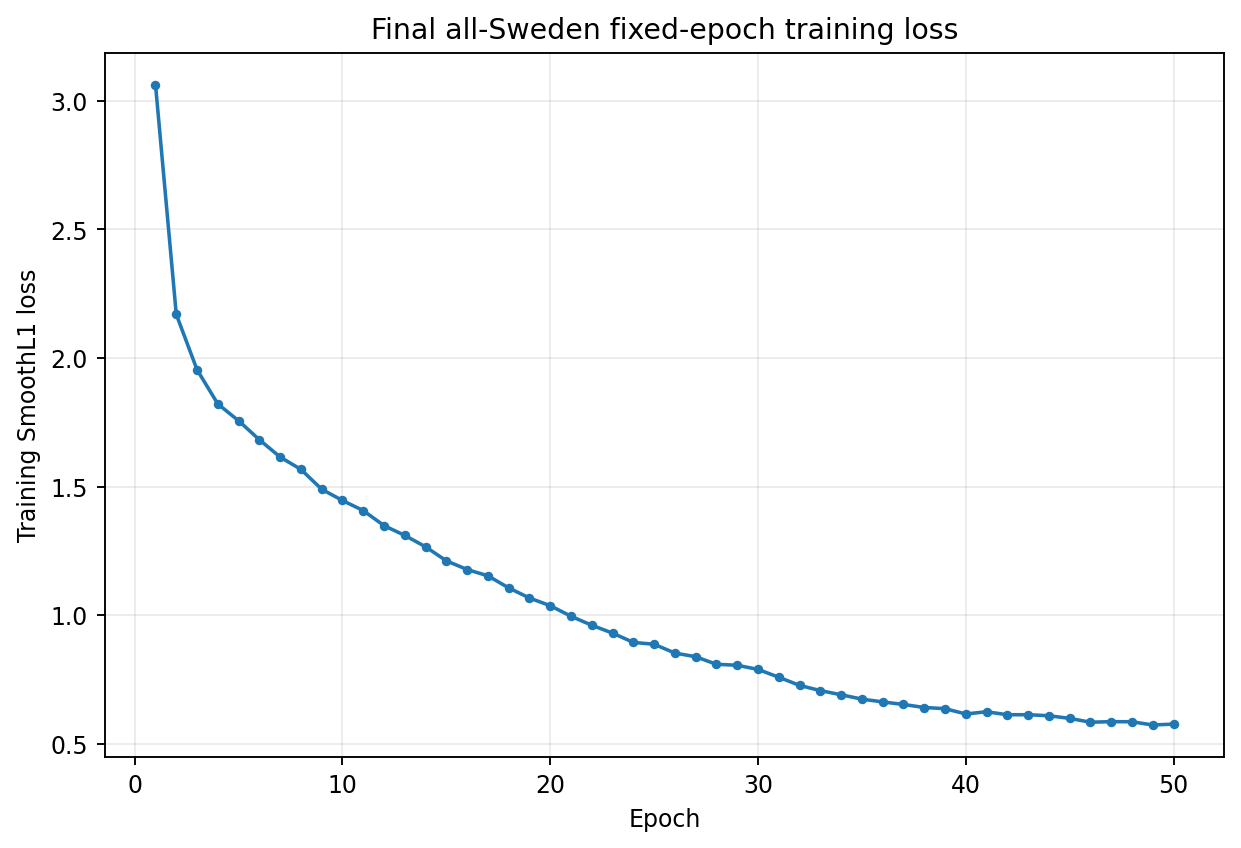

### APPARENT_final_model_ga_bin_patient_mae.png

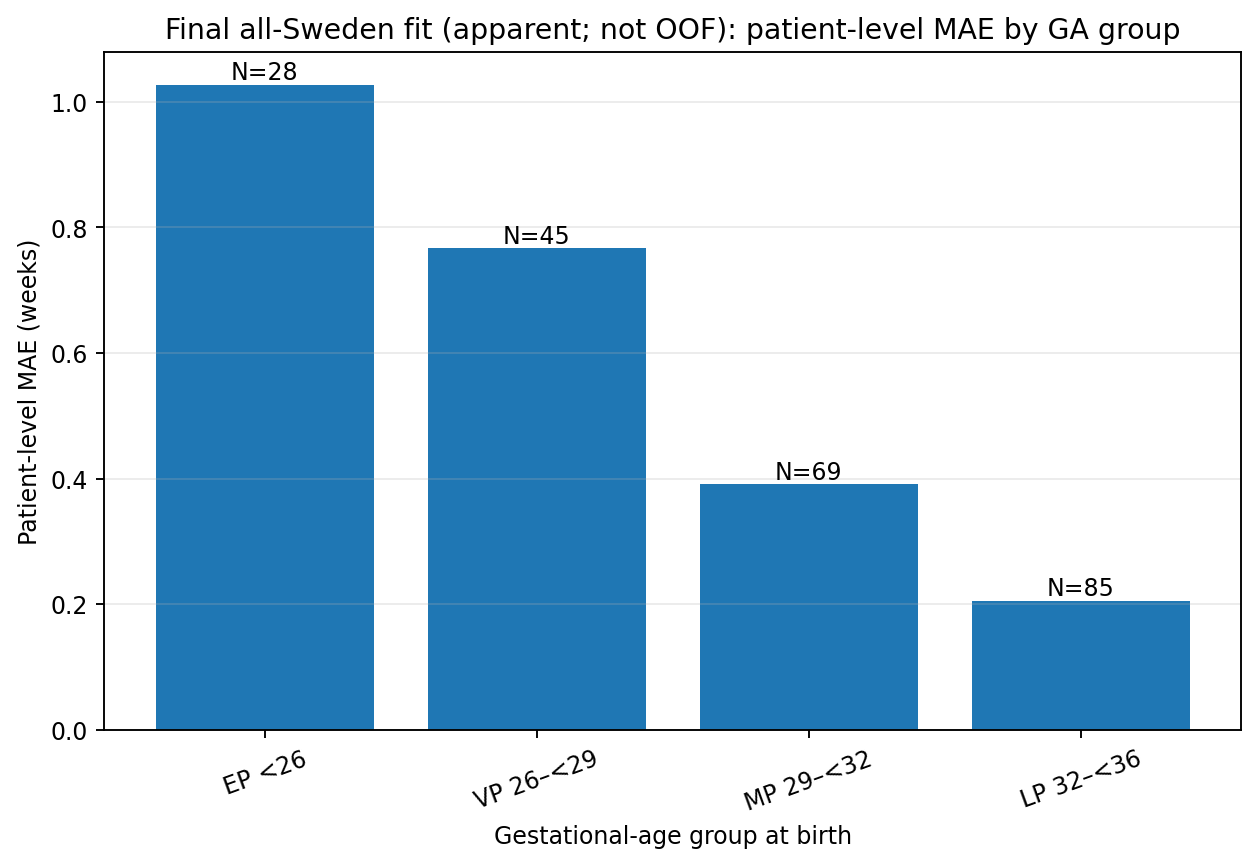

### APPARENT_final_model_ga_bin_patient_scatter.png

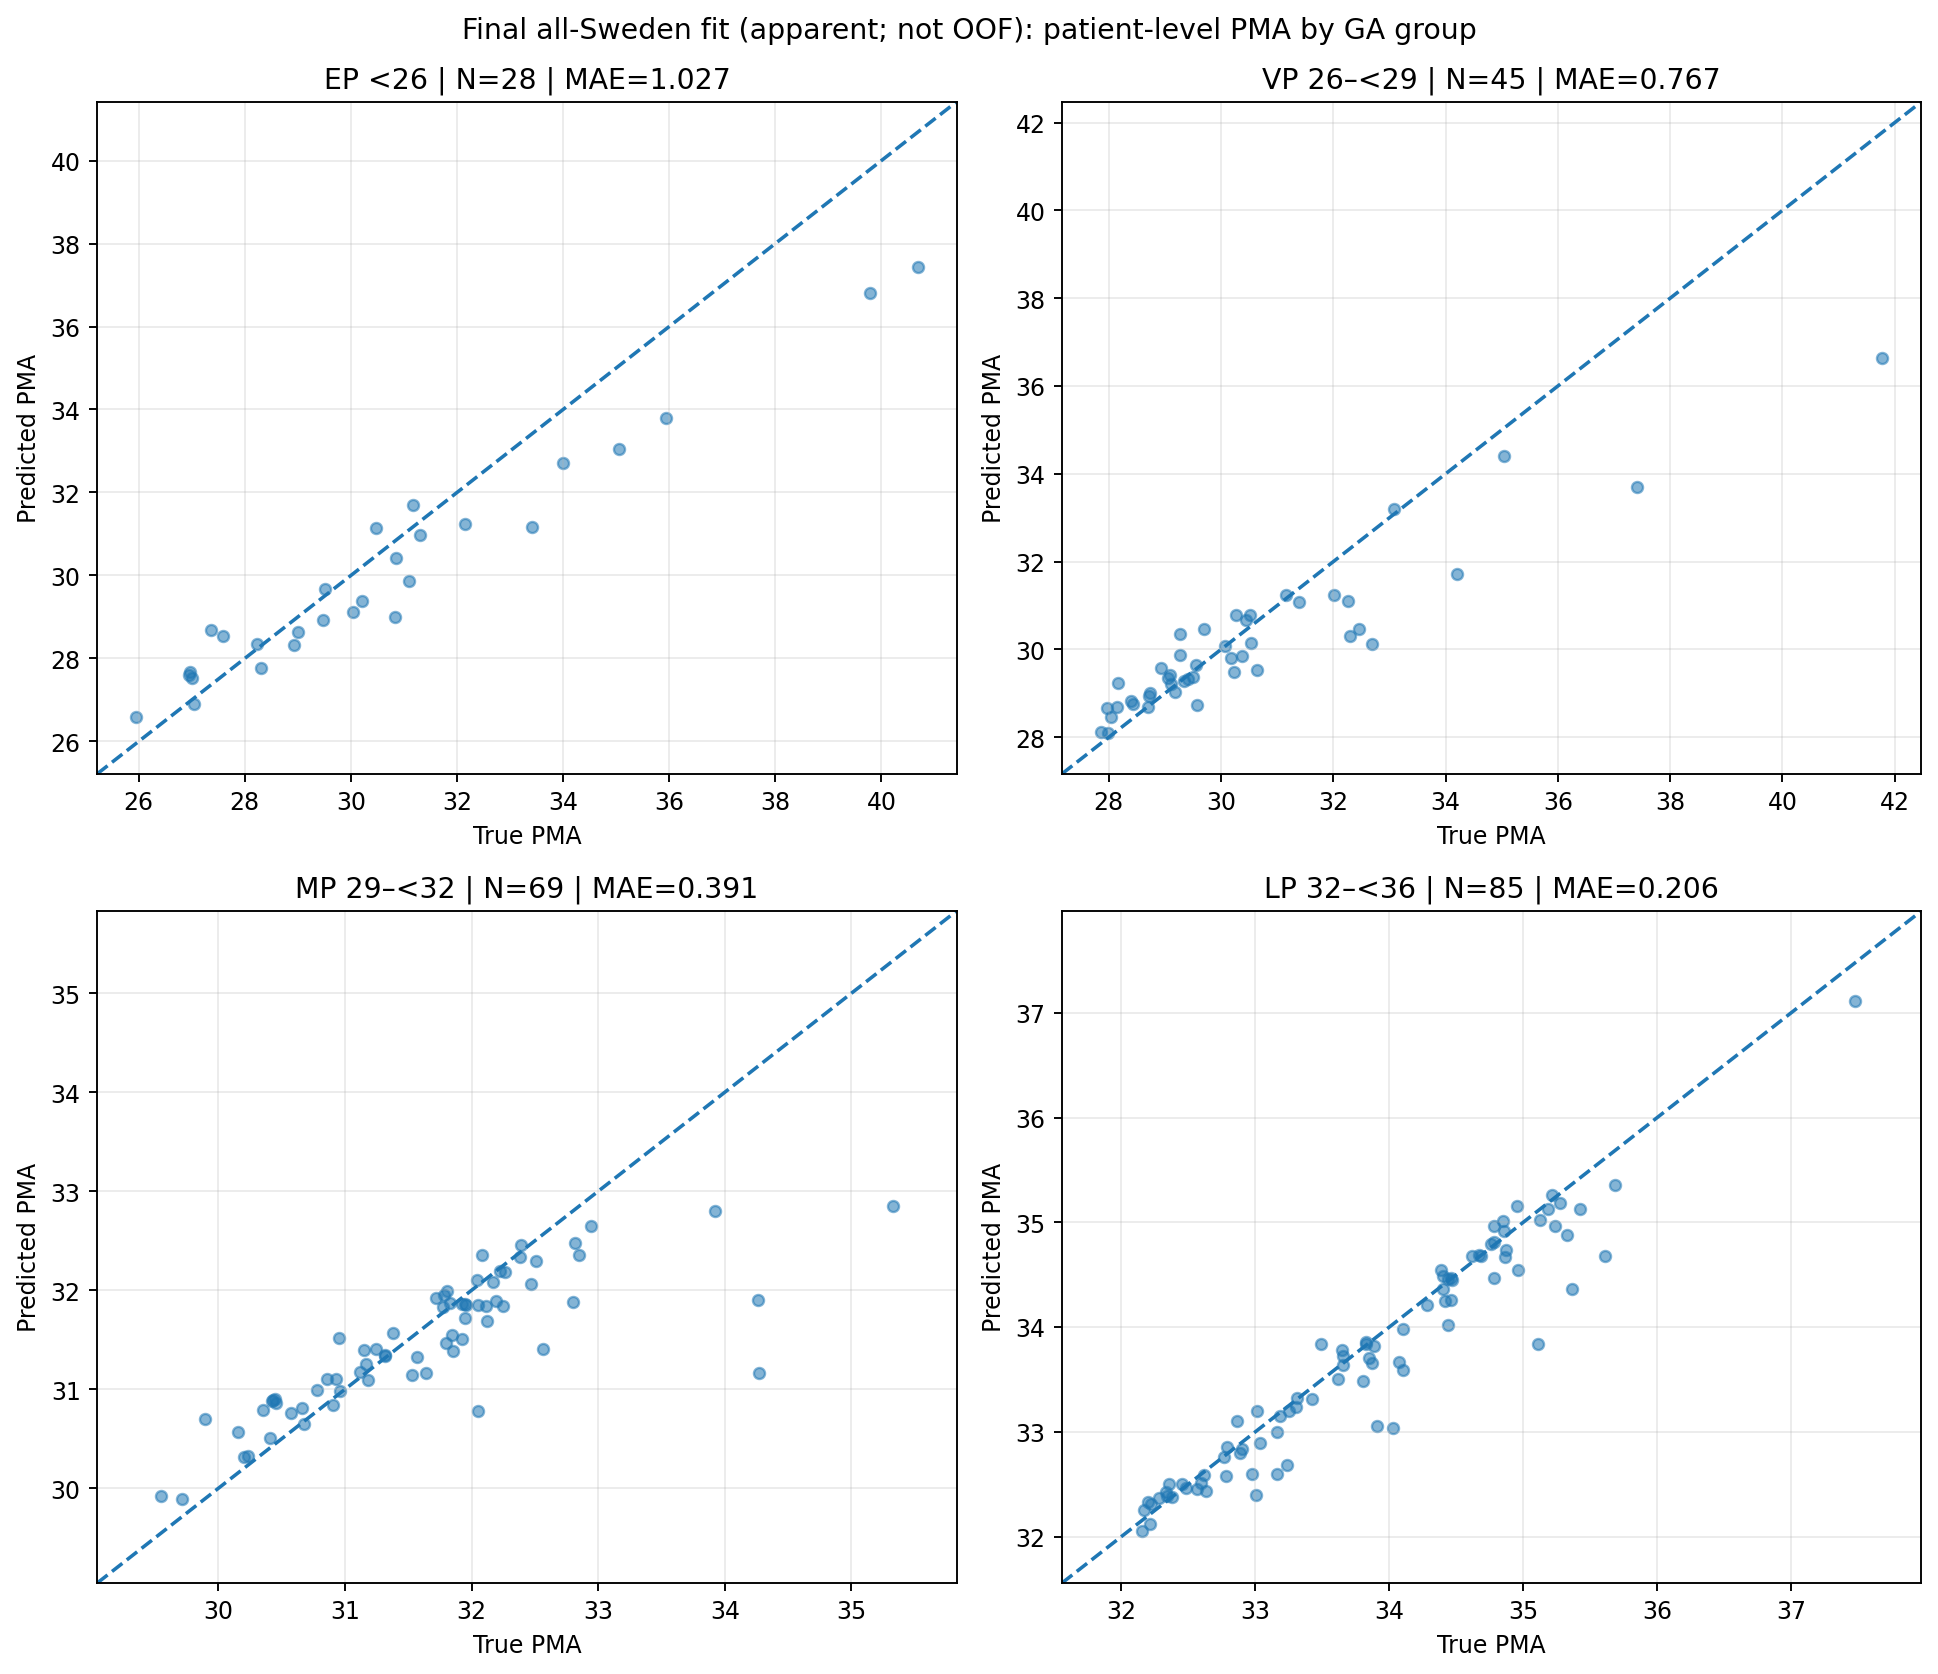

### APPARENT_final_model_overall_patient_scatter.png

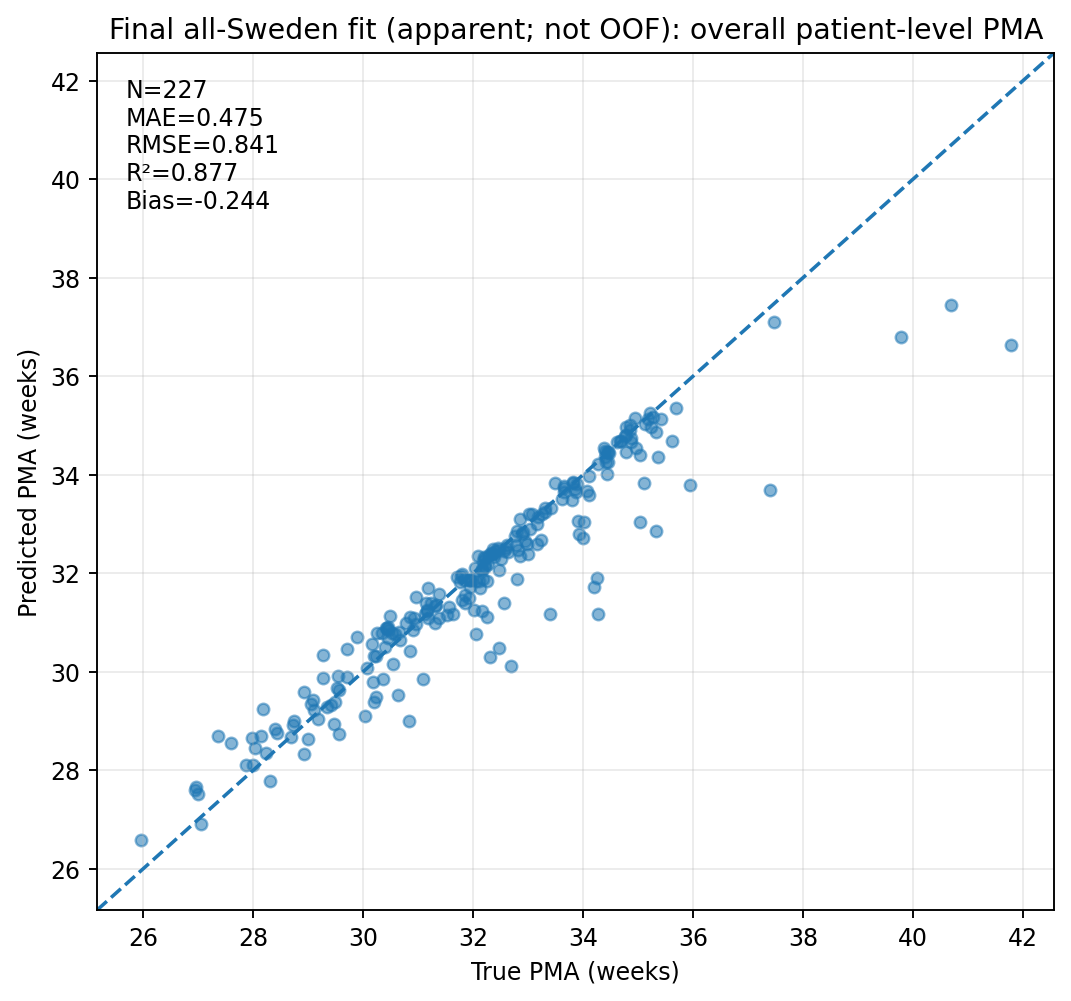

### APPARENT_final_model_overall_pma_bins.png

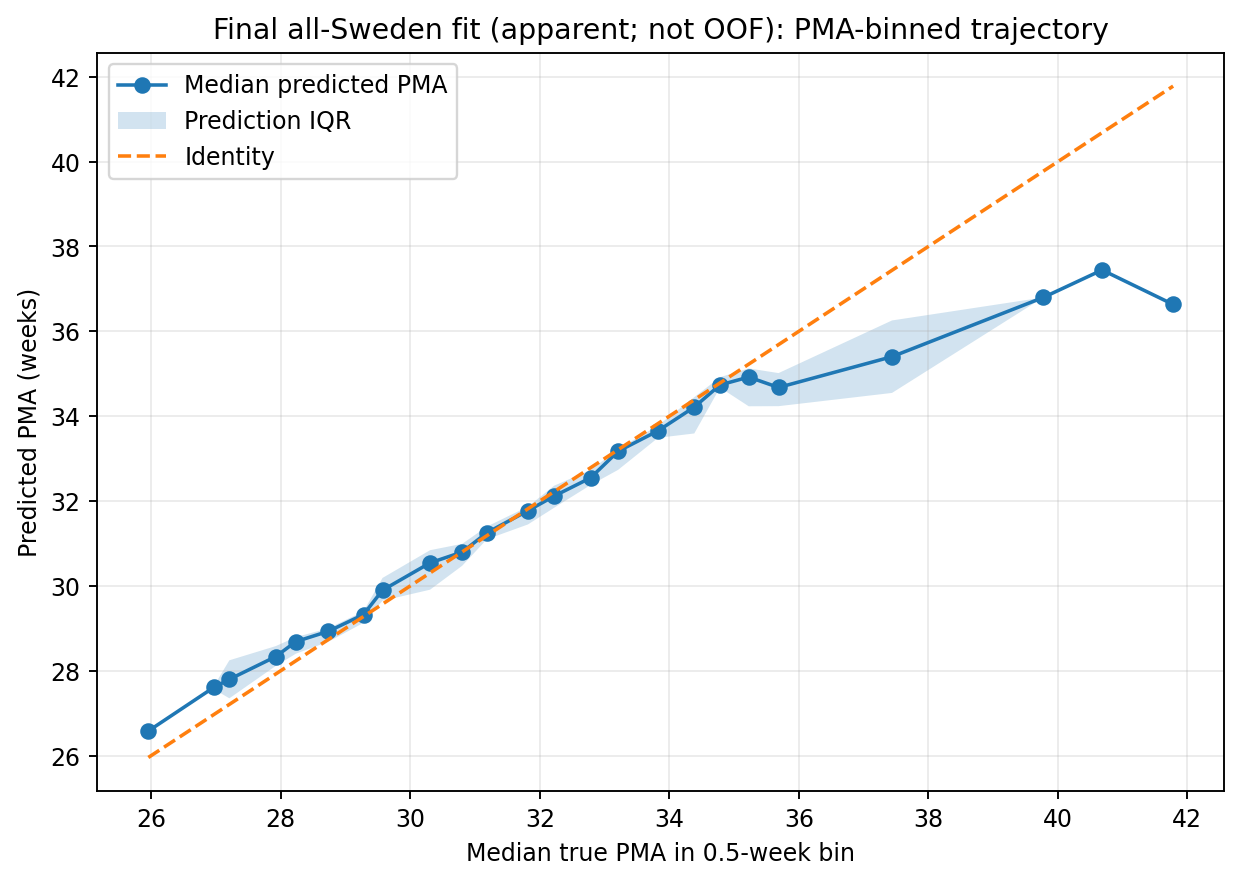

### NESTED_OOF_ga_bin_patient_mae.png

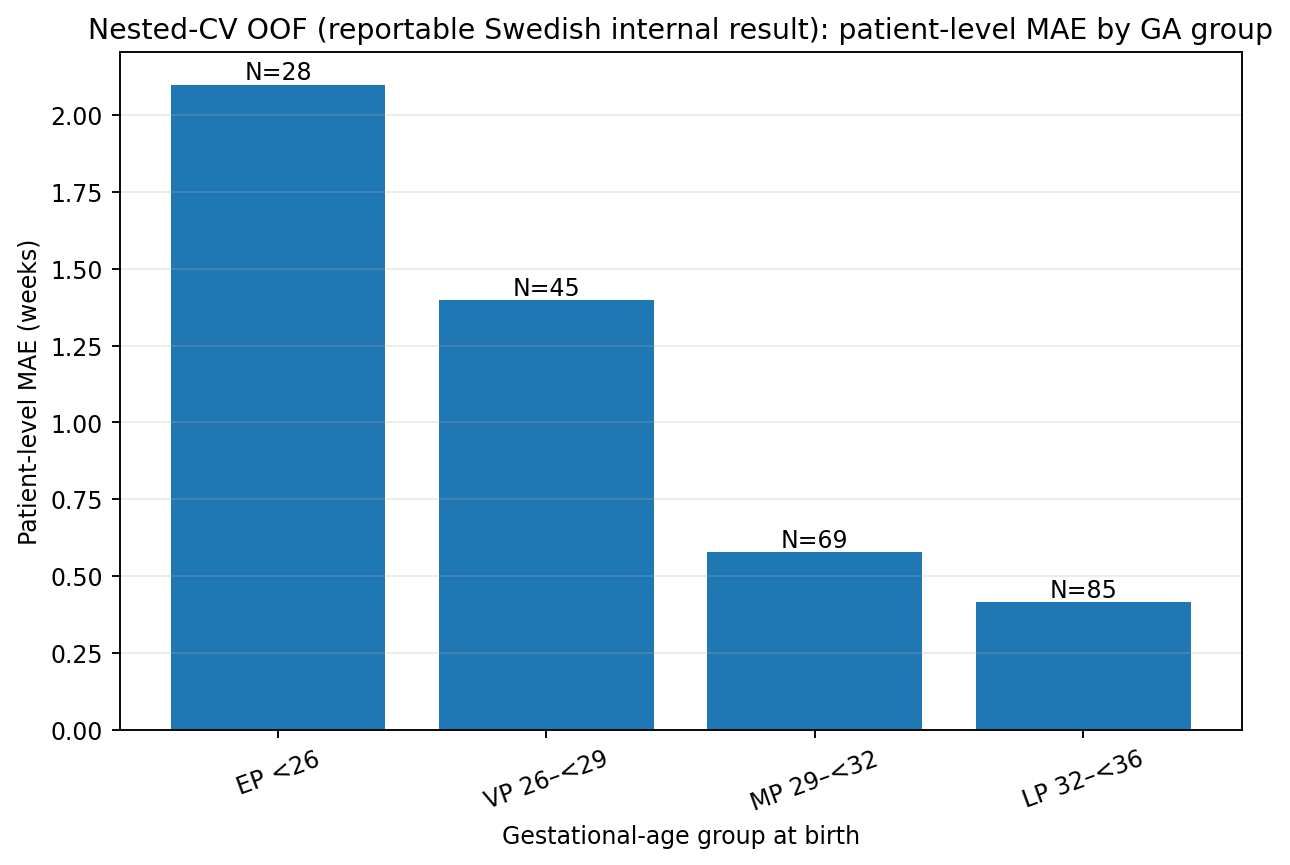

### NESTED_OOF_ga_bin_patient_scatter.png

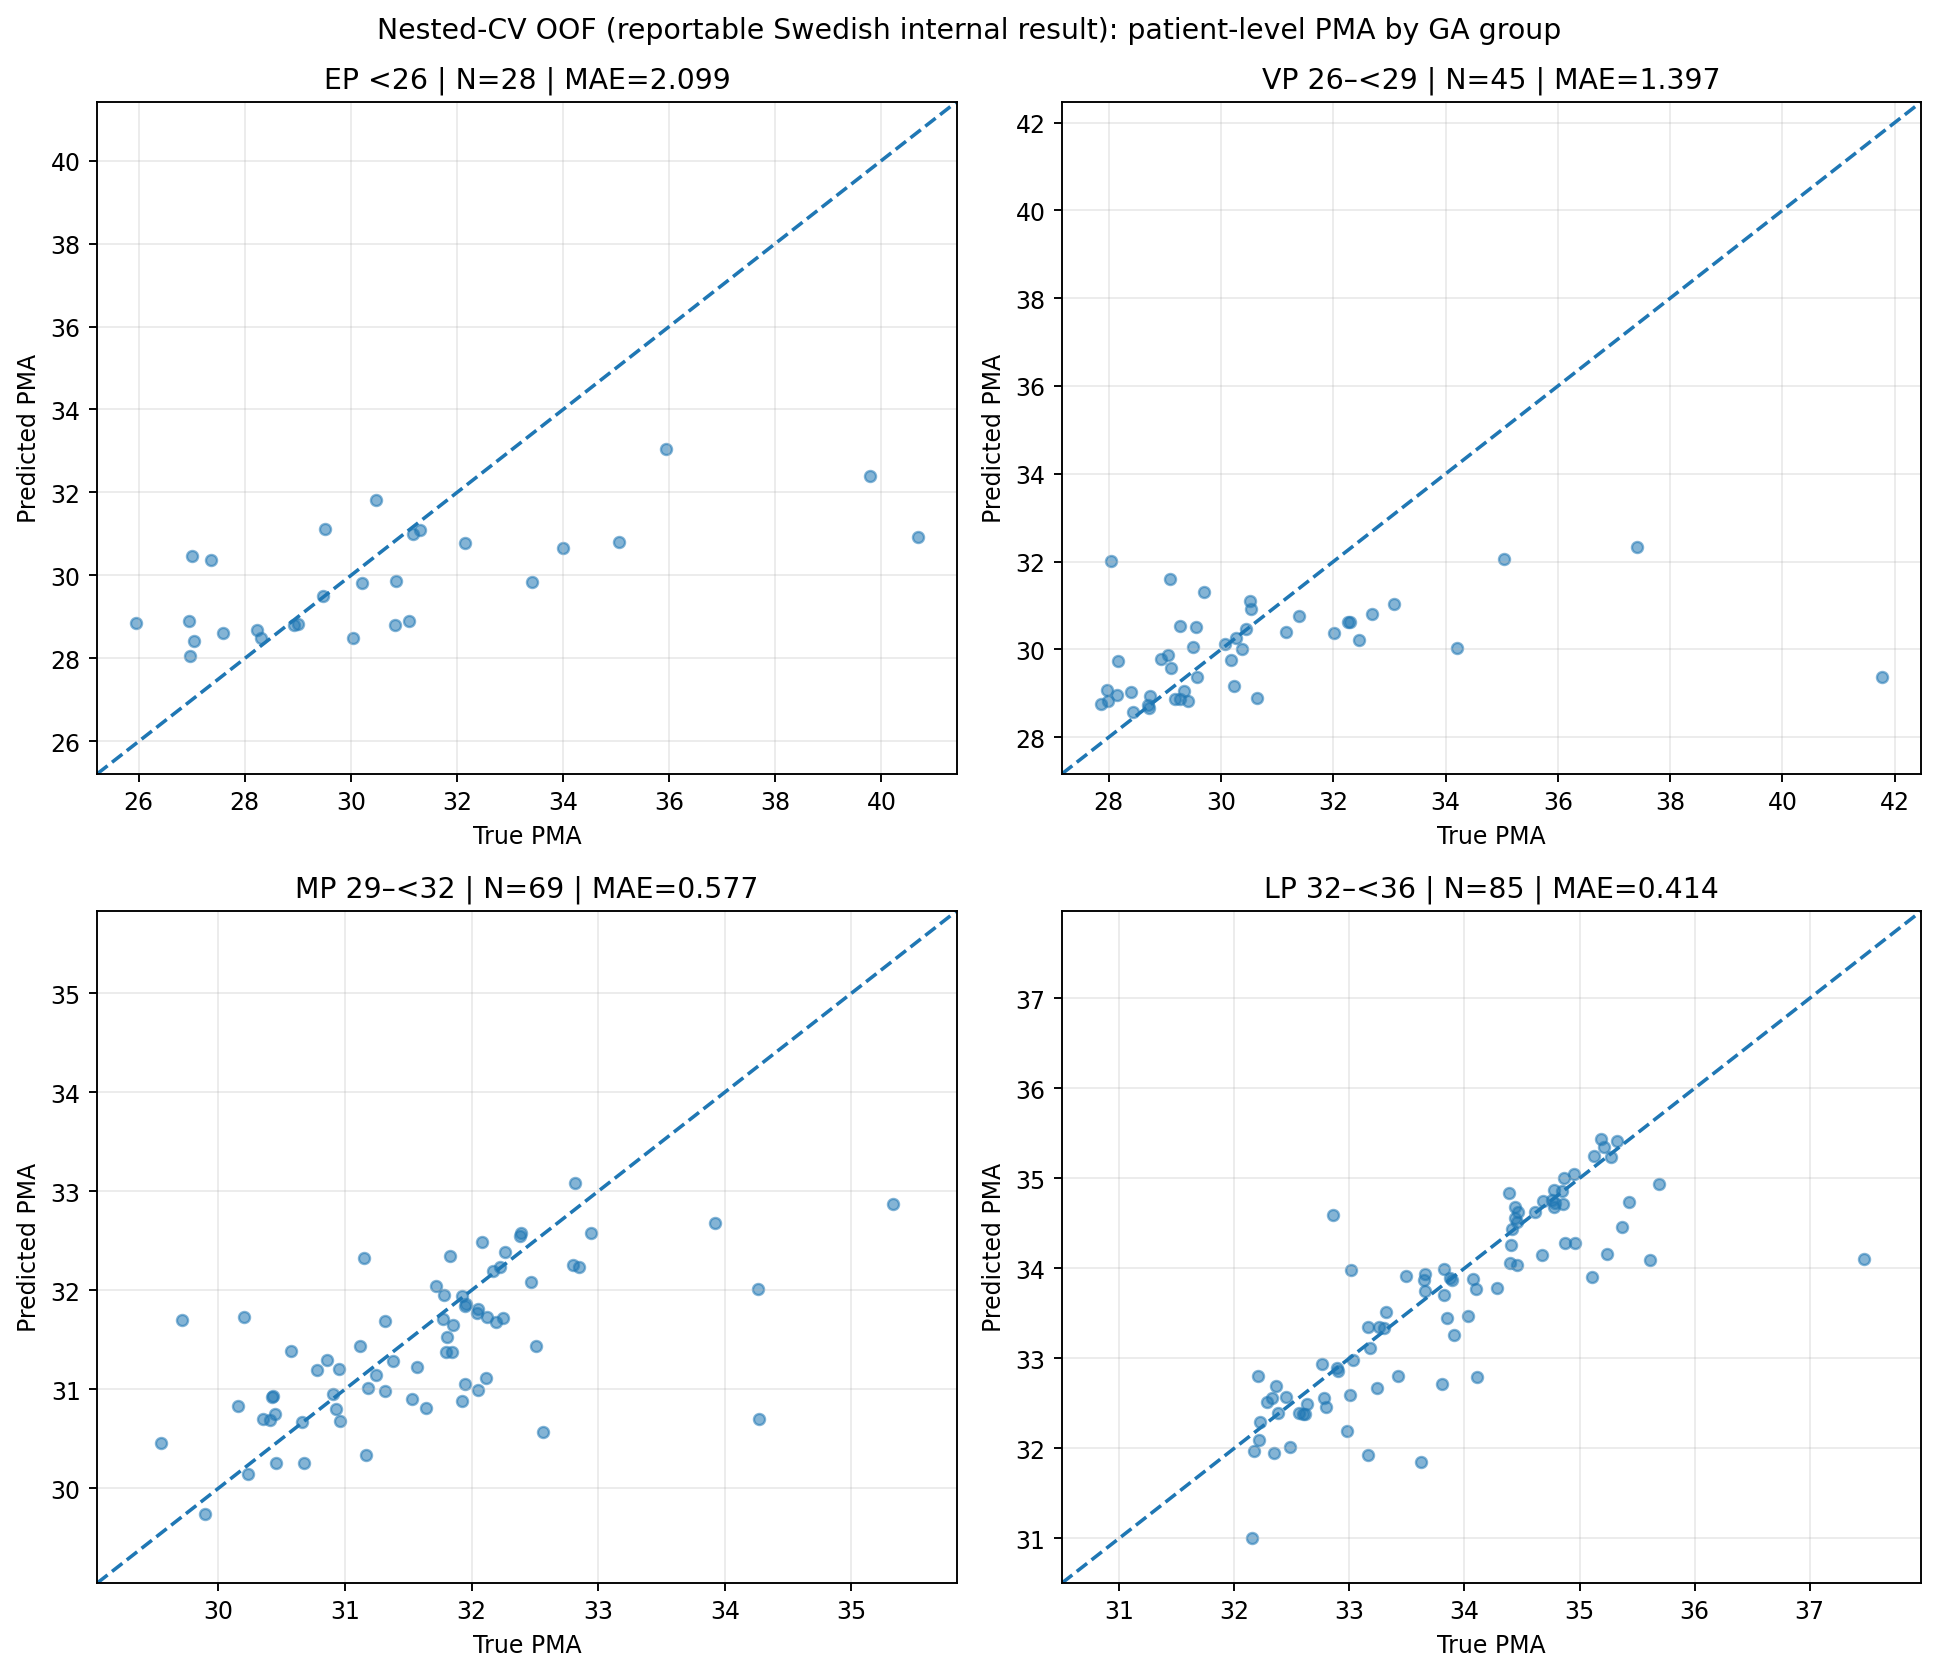

### NESTED_OOF_overall_patient_scatter.png

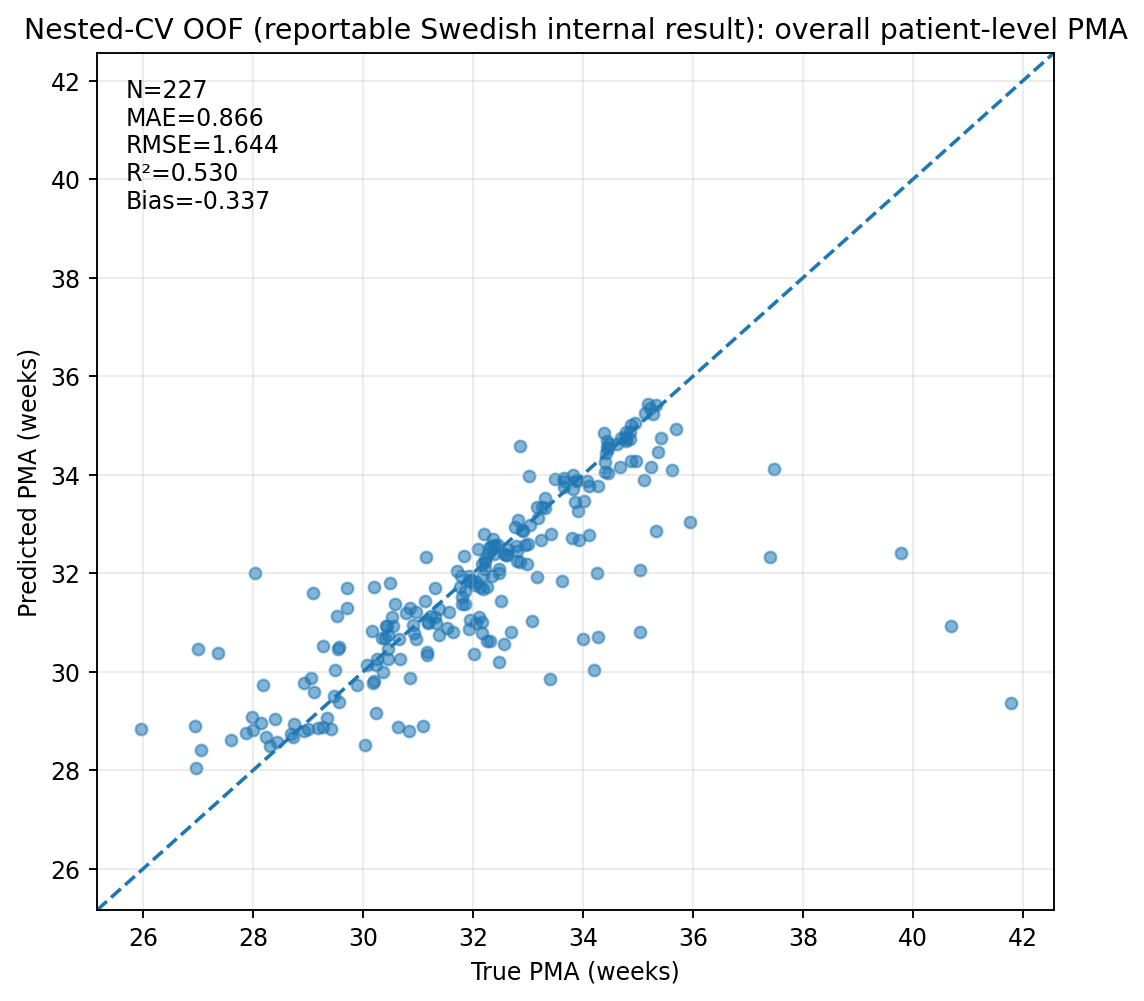

### NESTED_OOF_overall_pma_bins.png

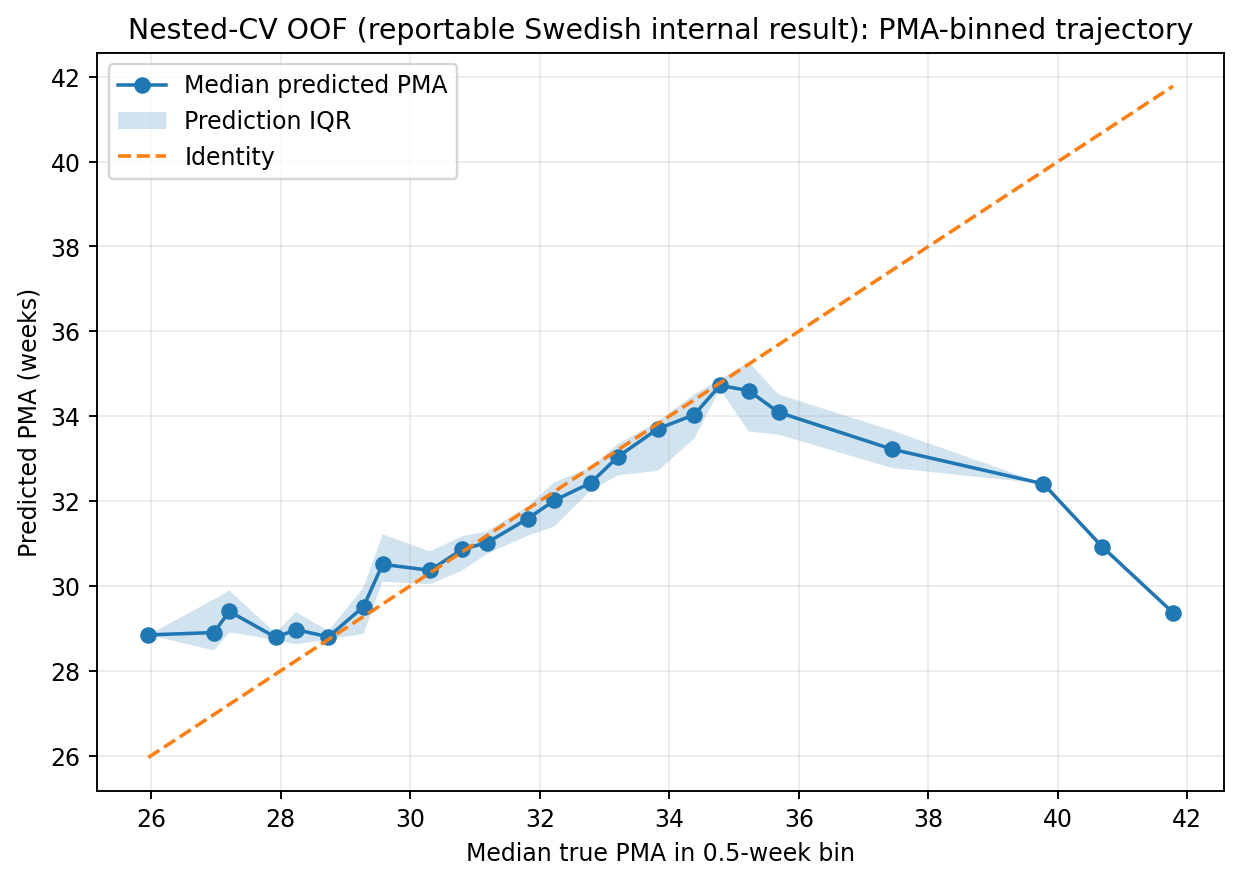

/mnt/home/qinqiu/thesis/result_val/final_all_sweden_common17_cnn_io_safe_median15/ga_bin_analysis/01_ga_bin_combined_scatter.png
Not generated yet.
/mnt/home/qinqiu/thesis/result_val/final_all_sweden_common17_cnn_io_safe_median15/ga_bin_analysis/02_ga_bin_binned_median_trajectory_with_count.png
Not generated yet.
/mnt/home/qinqiu/thesis/result_val/final_all_sweden_common17_cnn_io_safe_median15/ga_bin_analysis/03_ga_bin_4panel_trajectory.png
Not generated yet.


In [3]:
# Display the generated PNG figures after training completes.
from pathlib import Path
from IPython.display import display, Image, Markdown

figure_dir = Path(FINAL_EXP_ROOT) / "figures"
print("Figure directory:", figure_dir)

pngs = sorted(figure_dir.glob("*.png"))
if not pngs:
    print("No PNG files found yet. Complete the training cell first.")
else:
    for path in pngs:
        display(Markdown(f"### {path.name}"))
        display(Image(filename=str(path)))


from pathlib import Path
from IPython.display import display, Image, Markdown

ga_dir = Path(FINAL_EXP_ROOT) / "ga_bin_analysis"
for name in [
    "01_ga_bin_combined_scatter.png",
    "02_ga_bin_binned_median_trajectory_with_count.png",
    "03_ga_bin_4panel_trajectory.png",
]:
    p = ga_dir / name
    print(p)
    if p.exists():
        display(Markdown(f"### {name}"))
        display(Image(filename=str(p)))
    else:
        print("Not generated yet.")